In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, hamming_loss, f1_score, precision_score, recall_score, roc_auc_score, roc_curve
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [96]:
df=pd.read_csv("/kaggle/input/cdataset/Multilablel Cyberbully Data.csv")
df.sample(10)

,Gender,Profession,comment,bully,sexual,religious,threat,spam
8048,female,social,বেশ্বা,1,0,0,0,0
10760,female,actor,জুতা মেরে গরু দানবাহ মাগি বাহ,1,0,0,0,0
5076,male,social,সব গুলো কিউট,0,0,0,0,0
2085,male,politics,বোরকা সামিম ওসমান বলে কি মনে নাই বোরকা পরার কথা,1,0,0,0,0
8282,female,social,হে সেক্সি,1,1,0,0,0
6117,female,social,সাপোর্ট চাই আপু,0,0,0,0,1
2527,female,social,আসতাগফিরুল্লাহ,0,0,1,0,0
1662,male,sports,আসা ভাইয়া আপনের কি বোগল ই চুল উথে না,1,1,0,0,0
624,female,social,মাগির গুষ্টি মারি,1,1,0,0,0
8,female,dancer,আমি একজন কলেজ ছাত্রী টাকার অভাবে এই পথ বেছে নি...,0,1,0,0,1


In [97]:
#check the rows and columns number.
print(f"number of rows:--> {df.shape[0]} and number of columns:--> {df.shape[1]}")

number of rows:--> 12546 and number of columns:--> 8


In [98]:
#check for missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12546 entries, 0 to 12545
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Gender      12546 non-null  object
 1   Profession  12546 non-null  object
 2   comment     12546 non-null  object
 3   bully       12546 non-null  int64 
 4   sexual      12546 non-null  int64 
 5   religious   12546 non-null  int64 
 6   threat      12546 non-null  int64 
 7   spam        12546 non-null  int64 
dtypes: int64(5), object(3)
memory usage: 784.3+ KB


In [99]:
#check for missing values 
def checking_m(df):
    null_v = df.isnull().sum().sort_values(ascending=False)
    null_percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
    null_v = pd.concat([null_v, null_percent], axis=1, keys=['Missing_Number', 'Missing_Percent'])
    return null_v

checking_m(df)

,Missing_Number,Missing_Percent
Gender,0,0.0
Profession,0,0.0
comment,0,0.0
bully,0,0.0
sexual,0,0.0
religious,0,0.0
threat,0,0.0
spam,0,0.0


In [100]:
#check for dublicated rows
print("Numbers of duplicated rows :",df.duplicated().sum())

Numbers of duplicated rows : 1291


In [101]:
#counting text length
df['count'] = df['comment'].str.split().str.len()

# Remove the text with words less than 3
df= df.loc[df['count']>2]


In [102]:
df.shape

(10188, 9)

In [103]:
import re

def clean_bangla_text(text):
    # Remove English letters and digits only
    text = re.sub(r'[A-Za-z0-9]', '', text)

    # Remove unwanted punctuation (but keep । ! ? , )
    text = re.sub(r'[“”"\'’‘`^~–—…•°•→←<>/\\|_=+()*&^%$#@{}[\]<>]', ' ', text)

    # Remove newlines and tabs
    text = text.replace("\n", " ").replace("\t", " ")

    # Normalize multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['comment'] = df['comment'].apply(clean_bangla_text)

In [104]:
df.sample(10)

,Gender,Profession,comment,bully,sexual,religious,threat,spam,count
2749,female,social,আল্লাহ আমাদের বোঝার তৌফিক দান করুন আমিন,0,0,1,0,0,7
7852,female,social,আচ্ছা খুব জানতে ইচ্ছে করে আল্লাহ কে ভয় পায় না কেউ,0,0,1,0,0,11
8659,female,social,পইরাও এতো বড়ো,1,1,0,0,0,3
5603,female,actor,নামের পাশে নীল টিক চিহ্ন থাকাতে ভেবো না তুমি ব...,1,0,1,0,0,26
12018,female,actor,কী বলেন জুতা মেরে গুরু দান এটা বিশ্বাস করেন আল...,1,0,1,0,0,54
10645,female,actor,হায়রে নাড়ি জাত তরা কবে ভাল হবি,1,0,0,0,0,7
6392,female,social,খুব সুদোর হয়েছে ওয়াও,0,0,0,0,0,4
5115,male,social,এই কন্ঠে এক বার কোরআন তেলোয়াত সুনা না প্লিজ রি...,0,0,1,0,0,10
6723,female,dancer,তোমাকে চুদলে খুব ভালো লাগবে আপু,1,1,0,0,0,6
12502,male,social,নাস্তিক বা আস্তিক সবারই উপকার হবে বলে আশাকরি এ...,1,0,1,0,1,11


In [105]:
# Length of each cleaned comment (in tokens/words, split by space)
df['token_len'] = df['comment'].apply(lambda x: len(x.split()))

# Maximum token length
max_token_len = df['token_len'].max()

print("Maximum token length:", max_token_len)
df[['comment', 'token_len']].head()


Maximum token length: 178


,comment,token_len
0,এই দেশে এইসব কি হচ্ছে,5
1,মানে কি বলব,3
2,ভাই ভিডিও ফুল প্লিজ,4
3,নিজের খরচ নিজেই চালাতে পারবেন এমন ভালো একটা জব...,14
4,ভিডিও কলে রেগুলার কাজ করতে পারবেন,6


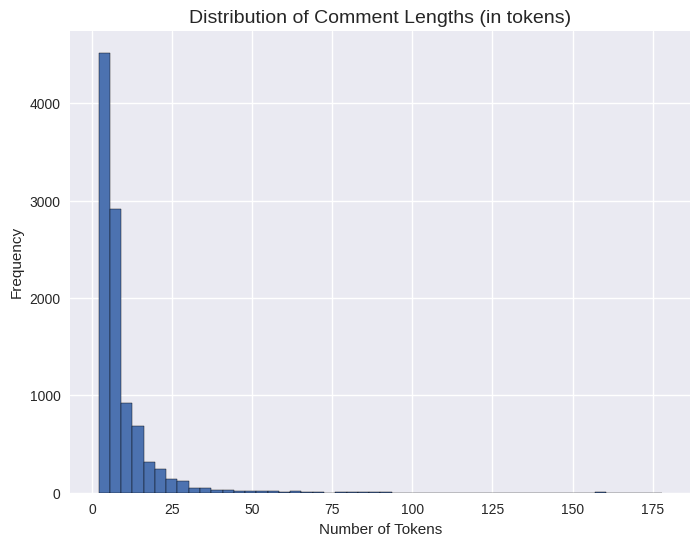

In [106]:
import matplotlib.pyplot as plt

# Distribution of token lengths (assuming you already added df['token_len'])
plt.figure(figsize=(8,6))
plt.hist(df['token_len'], bins=50, edgecolor='black')
plt.title("Distribution of Comment Lengths (in tokens)", fontsize=14)
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.show()


In [107]:
# Define label columns
label_cols = ['bully', 'sexual', 'religious', 'threat', 'spam']

# Prepare features and labels
texts = df['comment'].values
labels = df[label_cols].values.astype(np.float32)

labels

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 1.],
       ...,
       [1., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       [1., 0., 1., 0., 0.]], dtype=float32)

In [108]:
print(f"Dataset size: {len(texts)}")
print(f"Label distribution:\n{df[label_cols].sum()}")


Dataset size: 10188
Label distribution:
bully        6882
sexual       1802
religious    1445
threat       1403
spam          933
dtype: int64


In [109]:
# Train-validation-test split (80-10-10)
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels.sum(axis=1)
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp.sum(axis=1)
)

print(f"\nTrain: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


Train: 8150, Val: 1019, Test: 1019


In [110]:
import pandas as pd
from sklearn.utils import resample
import numpy as np

# ======================================================
# BALANCE (RESAMPLE) TRAINING DATA — Match to Max Class Count
# ======================================================

label_cols = ['bully', 'sexual', 'religious', 'threat', 'spam']

# Ensure DataFrame format
X_train_df = pd.DataFrame(X_train, columns=["comment"])
y_train_df = pd.DataFrame(y_train, columns=label_cols)

# Combine for easier handling
train_df = pd.concat([X_train_df.reset_index(drop=True), y_train_df.reset_index(drop=True)], axis=1)

print("\nOriginal training label distribution:")
print(train_df[label_cols].sum())

# -------------------------------------------------------
# Target = size of the largest class
# -------------------------------------------------------
max_count = int(train_df[label_cols].sum().max())
print(f"\n🎯 Target samples per class (max-upsampled): {max_count}")

# -------------------------------------------------------
# Upsample all minority classes to match the majority
# -------------------------------------------------------
resampled_dfs = [train_df]
generated_counts = {}

for label in label_cols:
    df_label = train_df[train_df[label] == 1]
    n_current = len(df_label)

    if n_current < max_count:
        df_upsampled = resample(
            df_label,
            replace=True,
            n_samples=max_count - n_current,
            random_state=42
        )
        resampled_dfs.append(df_upsampled)
        generated_counts[label] = len(df_upsampled)
    else:
        generated_counts[label] = 0

# Combine and shuffle
train_balanced = pd.concat(resampled_dfs).sample(frac=1, random_state=42).reset_index(drop=True)

# Split back into arrays for model training
X_train = train_balanced["comment"].reset_index(drop=True).values
y_train = train_balanced[label_cols].reset_index(drop=True).values.astype(np.float32)

# -------------------------------------------------------
# Summary
# -------------------------------------------------------
print("\n✅ Final balanced training distribution:")
print(train_balanced[label_cols].sum())

print("\n📈 Generated (added) samples per class:")
print(generated_counts)

print(f"\nTotal final balanced training size: {len(X_train)}")



Original training label distribution:
bully        5497.0
sexual       1447.0
religious    1160.0
threat       1116.0
spam          752.0
dtype: float32

🎯 Target samples per class (max-upsampled): 5497

✅ Final balanced training distribution:
bully        16472.0
sexual        6189.0
religious     7418.0
threat        6841.0
spam          5986.0
dtype: float32

📈 Generated (added) samples per class:
{'bully': 0, 'sexual': 4050, 'religious': 4337, 'threat': 4381, 'spam': 4745}

Total final balanced training size: 25663


In [112]:
len(X_train), len(y_train)

(25663, 25663)

# ======================== LSTM ========================

In [113]:
# ========================
# 3. MODEL ARCHITECTURE: LSTM Only
# ========================

class LSTMOnly(nn.Module):
    def __init__(self, vocab_size, embedding_dim=300, hidden_dim=256, num_layers=2, 
                 num_labels=5, dropout=0.3, padding_idx=0):
        super(LSTMOnly, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_labels)
        
    def forward(self, input_ids, attention_mask=None):
        # input_ids shape: (batch_size, seq_length)
        embeddings = self.embedding(input_ids)  # (batch_size, seq_length, embedding_dim)
        
        lstm_output, (hidden, cell) = self.lstm(embeddings)
        # Concatenate last hidden states from both directions
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        
        hidden = self.dropout(hidden)
        logits = self.classifier(hidden)
        return logits


In [114]:
# ========================
# 4. DATA PREPARATION FOR LSTM
# ========================

# We need to create a vocabulary and update the dataset class
class LSTMDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, vocab, max_len=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.vocab = vocab
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Simple tokenization (split by space)
        tokens = text.split()[:self.max_len]
        
        # Convert tokens to indices
        input_ids = [self.vocab.get(token, self.vocab['<UNK>']) for token in tokens]
        
        # Padding
        if len(input_ids) < self.max_len:
            input_ids = input_ids + [self.vocab['<PAD>']] * (self.max_len - len(input_ids))
        else:
            input_ids = input_ids[:self.max_len]
        
        attention_mask = [1 if token != self.vocab['<PAD>'] else 0 for token in input_ids]
        
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'labels': torch.tensor(label, dtype=torch.float)
        }

In [115]:
# Build vocabulary
def build_vocab(texts, min_freq=2):
    vocab = {'<PAD>': 0, '<UNK>': 1}
    word_freq = {}
    
    # Count word frequencies
    for text in texts:
        tokens = str(text).split()
        for token in tokens:
            word_freq[token] = word_freq.get(token, 0) + 1
    
    # Add words to vocabulary based on frequency
    idx = 2
    for word, freq in word_freq.items():
        if freq >= min_freq:
            vocab[word] = idx
            idx += 1
    
    return vocab

In [116]:
# ========================
# 5. MAIN TRAINING PIPELINE - LSTMOnly
# ========================

# Configuration
MAX_LEN = 64
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-3
EMBEDDING_DIM = 300
HIDDEN_DIM = 256
LSTM_LAYERS = 2

# Build vocabulary from training data
print("Building vocabulary...")
vocab = build_vocab(X_train)
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")

# Create datasets
train_dataset = LSTMDataset(X_train, y_train, None, vocab, MAX_LEN)
val_dataset = LSTMDataset(X_val, y_val, None, vocab, MAX_LEN)
test_dataset = LSTMDataset(X_test, y_test, None, vocab, MAX_LEN)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Initialize LSTM-only model
model = LSTMOnly(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=LSTM_LAYERS,
    num_labels=len(label_cols)
).to(device)

print(f"\nModel: LSTMOnly")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Building vocabulary...
Vocabulary size: 9718

Model: LSTMOnly
Total parameters: 5,637,709


In [117]:
def train_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    progress_bar = tqdm(dataloader, desc='Training')
    
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        logits = model(input_ids, attention_mask)
        loss = nn.BCEWithLogitsLoss()(logits, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        
        # Calculate accuracy
        preds = torch.sigmoid(logits) > 0.5
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        progress_bar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    
    return avg_loss, accuracy

def eval_epoch(model, dataloader, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    progress_bar = tqdm(dataloader, desc='Validation')
    
    with torch.no_grad():
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            logits = model(input_ids, attention_mask)
            loss = nn.BCEWithLogitsLoss()(logits, labels)
            
            total_loss += loss.item()
            
            probs = torch.sigmoid(logits)
            preds = probs > 0.5
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
            progress_bar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    
    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels), np.array(all_probs)


In [118]:
# Optimizer (different learning rate for LSTM)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

In [119]:
# ========================
# 6. TRAINING LOOP - LSTMOnly
# ========================

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\n" + "="*50)
print("STARTING TRAINING - LSTMOnly")
print("="*50)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 50)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    
    # Validate
    val_loss, val_acc, _, _, _ = eval_epoch(model, val_loader, device)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Save last model checkpoint (not best)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'vocab': vocab,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_acc': train_acc,
        'val_acc': val_acc
    }, 'last_model_checkpoint_lstm_only.pt')
    print(f"✓ Last LSTMOnly model checkpoint saved! (Epoch {epoch+1})")

print("\n" + "="*50)
print("TRAINING COMPLETED - LSTMOnly")
print("="*50)

# Print final training and validation metrics
print(f"\nFINAL TRAINING METRICS - LSTMOnly:")
print(f"Last Train Loss: {history['train_loss'][-1]:.4f}")
print(f"Last Train Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Last Validation Loss: {history['val_loss'][-1]:.4f}")
print(f"Last Validation Accuracy: {history['val_acc'][-1]:.4f}")


STARTING TRAINING - LSTMOnly

Epoch 1/10
--------------------------------------------------


Training:   0%|          | 0/802 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.3016 | Train Acc: 0.8673
Val Loss: 0.3889 | Val Acc: 0.8732
✓ Last LSTMOnly model checkpoint saved! (Epoch 1)

Epoch 2/10
--------------------------------------------------


Training:   0%|          | 0/802 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.0103 | Train Acc: 0.9957
Val Loss: 0.5685 | Val Acc: 0.9070
✓ Last LSTMOnly model checkpoint saved! (Epoch 9)

Epoch 10/10
--------------------------------------------------


Training:   0%|          | 0/802 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.0092 | Train Acc: 0.9961
Val Loss: 0.5899 | Val Acc: 0.9070
✓ Last LSTMOnly model checkpoint saved! (Epoch 10)

TRAINING COMPLETED - LSTMOnly

FINAL TRAINING METRICS - LSTMOnly:
Last Train Loss: 0.0092
Last Train Accuracy: 0.9961
Last Validation Loss: 0.5899
Last Validation Accuracy: 0.9070


In [120]:
# ========================
# 7. TEST EVALUATION - LSTMOnly
# ========================

print("\n" + "="*50)
print("TESTING WITH LAST LSTMOnly MODEL")
print("="*50)

# # Load last model checkpoint
# checkpoint = torch.load('last_model_checkpoint_lstm_only.pt')
# model.load_state_dict(checkpoint['model_state_dict'])

# Evaluate on test set
test_loss, test_acc, test_preds, test_labels, test_probs = eval_epoch(model, test_loader, device)

print(f"\n{'='*50}")
print(f"TEST RESULTS - LSTMOnly")
print(f"{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Hamming Loss: {hamming_loss(test_labels, test_preds):.4f}")


TESTING WITH LAST LSTMOnly MODEL


Validation:   0%|          | 0/32 [00:00<?, ?it/s]


TEST RESULTS - LSTMOnly
Test Loss: 0.5970
Test Accuracy: 0.9050
Hamming Loss: 0.0950


In [121]:
# Calculate precision, recall, F1 scores
precision = precision_score(test_labels, test_preds, average='micro', zero_division=0)
recall = recall_score(test_labels, test_preds, average='micro', zero_division=0)
f1 = f1_score(test_labels, test_preds, average='micro', zero_division=0)

print(f"\nOverall Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")



Overall Metrics:
Precision: 0.8634
Recall: 0.7261
F1-Score: 0.7888


In [122]:

# ========================
# MCC AND COHEN'S KAPPA SCORES
# ========================

from sklearn.metrics import matthews_corrcoef, cohen_kappa_score
import numpy as np

# Convert to numpy arrays
test_labels_np = np.array(test_labels)
test_preds_np = np.array(test_preds)

class_names = ['bully', 'sexual', 'religious', 'threat', 'spam']

print(f"\n{'='*50}")
print(f"MCC AND COHEN'S KAPPA SCORES")
print(f"{'='*50}")

# Calculate for each class
mcc_scores = []
kappa_scores = []

print("\nPer-class Scores:")
for i, class_name in enumerate(class_names):
    mcc = matthews_corrcoef(test_labels_np[:, i], test_preds_np[:, i])
    kappa = cohen_kappa_score(test_labels_np[:, i], test_preds_np[:, i])
    
    mcc_scores.append(mcc)
    kappa_scores.append(kappa)
    
    print(f"{class_name:>10}: MCC = {mcc:.4f}, Cohen's Kappa = {kappa:.4f}")

# Calculate averages
average_mcc = np.mean(mcc_scores)
average_kappa = np.mean(kappa_scores)

print(f"\nAverage Scores:")
print(f"MCC: {average_mcc:.4f}")
print(f"Cohen's Kappa: {average_kappa:.4f}")


MCC AND COHEN'S KAPPA SCORES

Per-class Scores:
     bully: MCC = 0.6267, Cohen's Kappa = 0.6265
    sexual: MCC = 0.4863, Cohen's Kappa = 0.4658
 religious: MCC = 0.7356, Cohen's Kappa = 0.7102
    threat: MCC = 0.5779, Cohen's Kappa = 0.5412
      spam: MCC = 0.7334, Cohen's Kappa = 0.7298

Average Scores:
MCC: 0.6320
Cohen's Kappa: 0.6147


In [123]:
# Per-label metrics
print(f"\n{'='*50}")
print("PER-LABEL CLASSIFICATION REPORT - LSTMOnly")
print(f"{'='*50}")
print(classification_report(
    test_labels, 
    test_preds, 
    target_names=label_cols,
    zero_division=0
))


PER-LABEL CLASSIFICATION REPORT - LSTMOnly
              precision    recall  f1-score   support

       bully       0.88      0.89      0.88       693
      sexual       0.71      0.42      0.53       155
   religious       0.97      0.60      0.74       143
      threat       0.86      0.45      0.59       164
        spam       0.83      0.69      0.75        90

   micro avg       0.86      0.73      0.79      1245
   macro avg       0.85      0.61      0.70      1245
weighted avg       0.86      0.73      0.77      1245
 samples avg       0.69      0.62      0.64      1245



In [124]:
# Calculate AUC-ROC for each class
print(f"\n{'='*50}")
print("AUC-ROC SCORES FOR EACH CLASS - LSTMOnly")
print(f"{'='*50}")
for i, label in enumerate(label_cols):
    try:
        auc = roc_auc_score(test_labels[:, i], test_probs[:, i])
        print(f"{label}: {auc:.4f}")
    except ValueError:
        print(f"{label}: Could not calculate AUC (only one class present)")

# Calculate overall micro and macro AUC
try:
    micro_auc = roc_auc_score(test_labels, test_probs, average='micro')
    macro_auc = roc_auc_score(test_labels, test_probs, average='macro')
    print(f"\nMicro AUC: {micro_auc:.4f}")
    print(f"Macro AUC: {macro_auc:.4f}")
except ValueError:
    print("\nCould not calculate overall AUC scores")


AUC-ROC SCORES FOR EACH CLASS - LSTMOnly
bully: 0.9042
sexual: 0.8439
religious: 0.9163
threat: 0.8828
spam: 0.9255

Micro AUC: 0.9353
Macro AUC: 0.8945


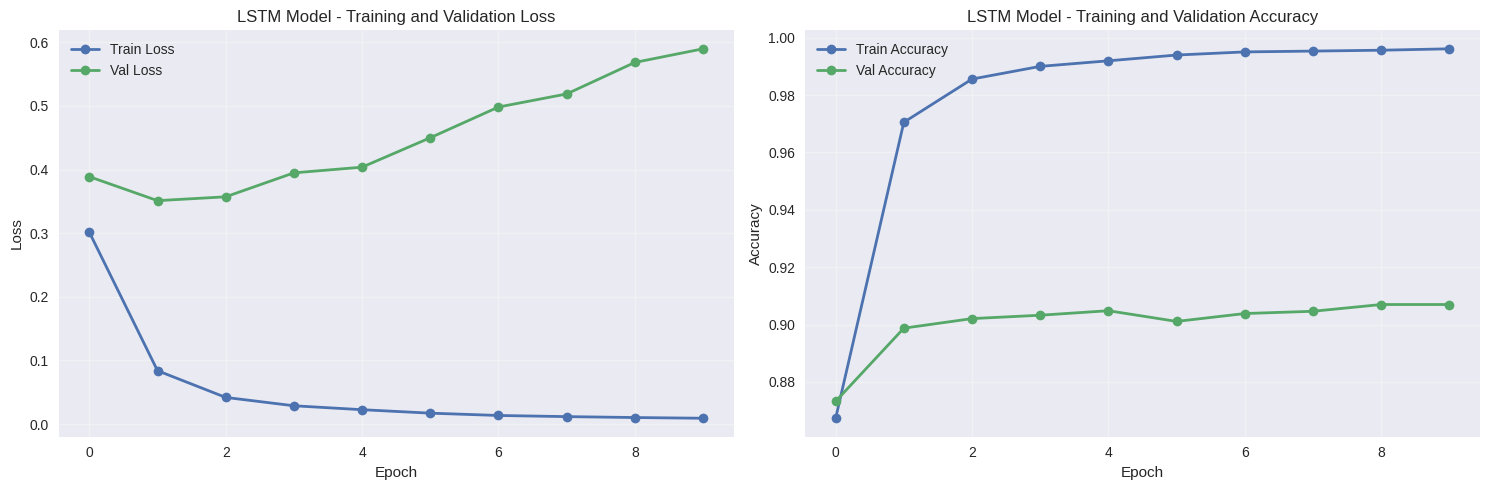

In [125]:
# ========================
# 9. PLOT TRAINING HISTORY - LSTMOnly
# ========================

plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', marker='o', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('LSTM Model - Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='o', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('LSTM Model - Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('LSTMOnly_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

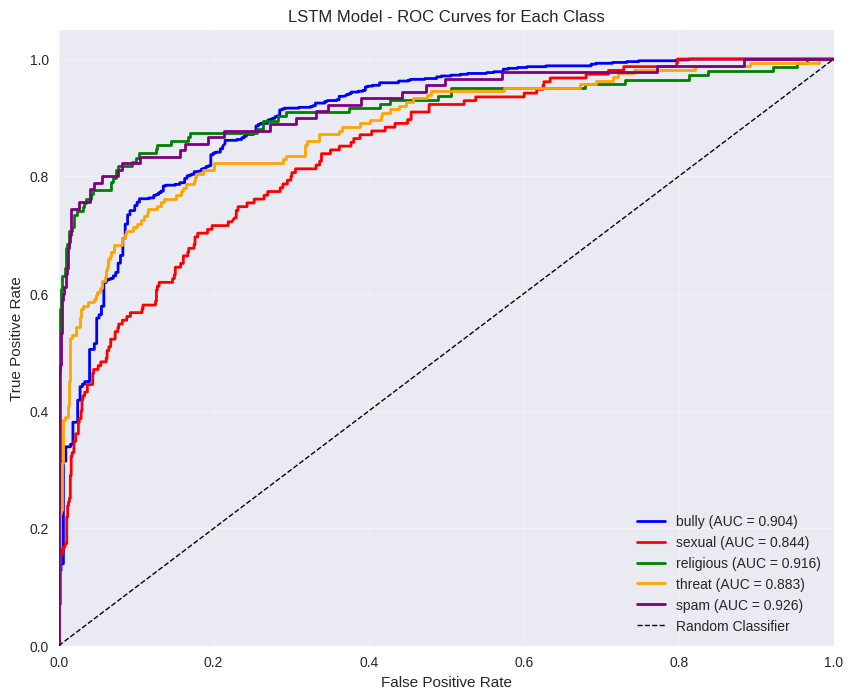

In [126]:
# ========================
# 10. PLOT ROC CURVES - LSTMOnly
# ========================

# Plot ROC curves for each class
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple']

for i, label in enumerate(label_cols):
    try:
        fpr, tpr, _ = roc_curve(test_labels[:, i], test_probs[:, i])
        auc = roc_auc_score(test_labels[:, i], test_probs[:, i])
        plt.plot(fpr, tpr, color=colors[i], linewidth=2, 
                label=f'{label} (AUC = {auc:.3f})')
    except ValueError:
        continue

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LSTM Model - ROC Curves for Each Class')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('LSTMOnly_ROC_curves.png', dpi=300, bbox_inches='tight')
plt.show()


COMPREHENSIVE CONFUSION MATRIX


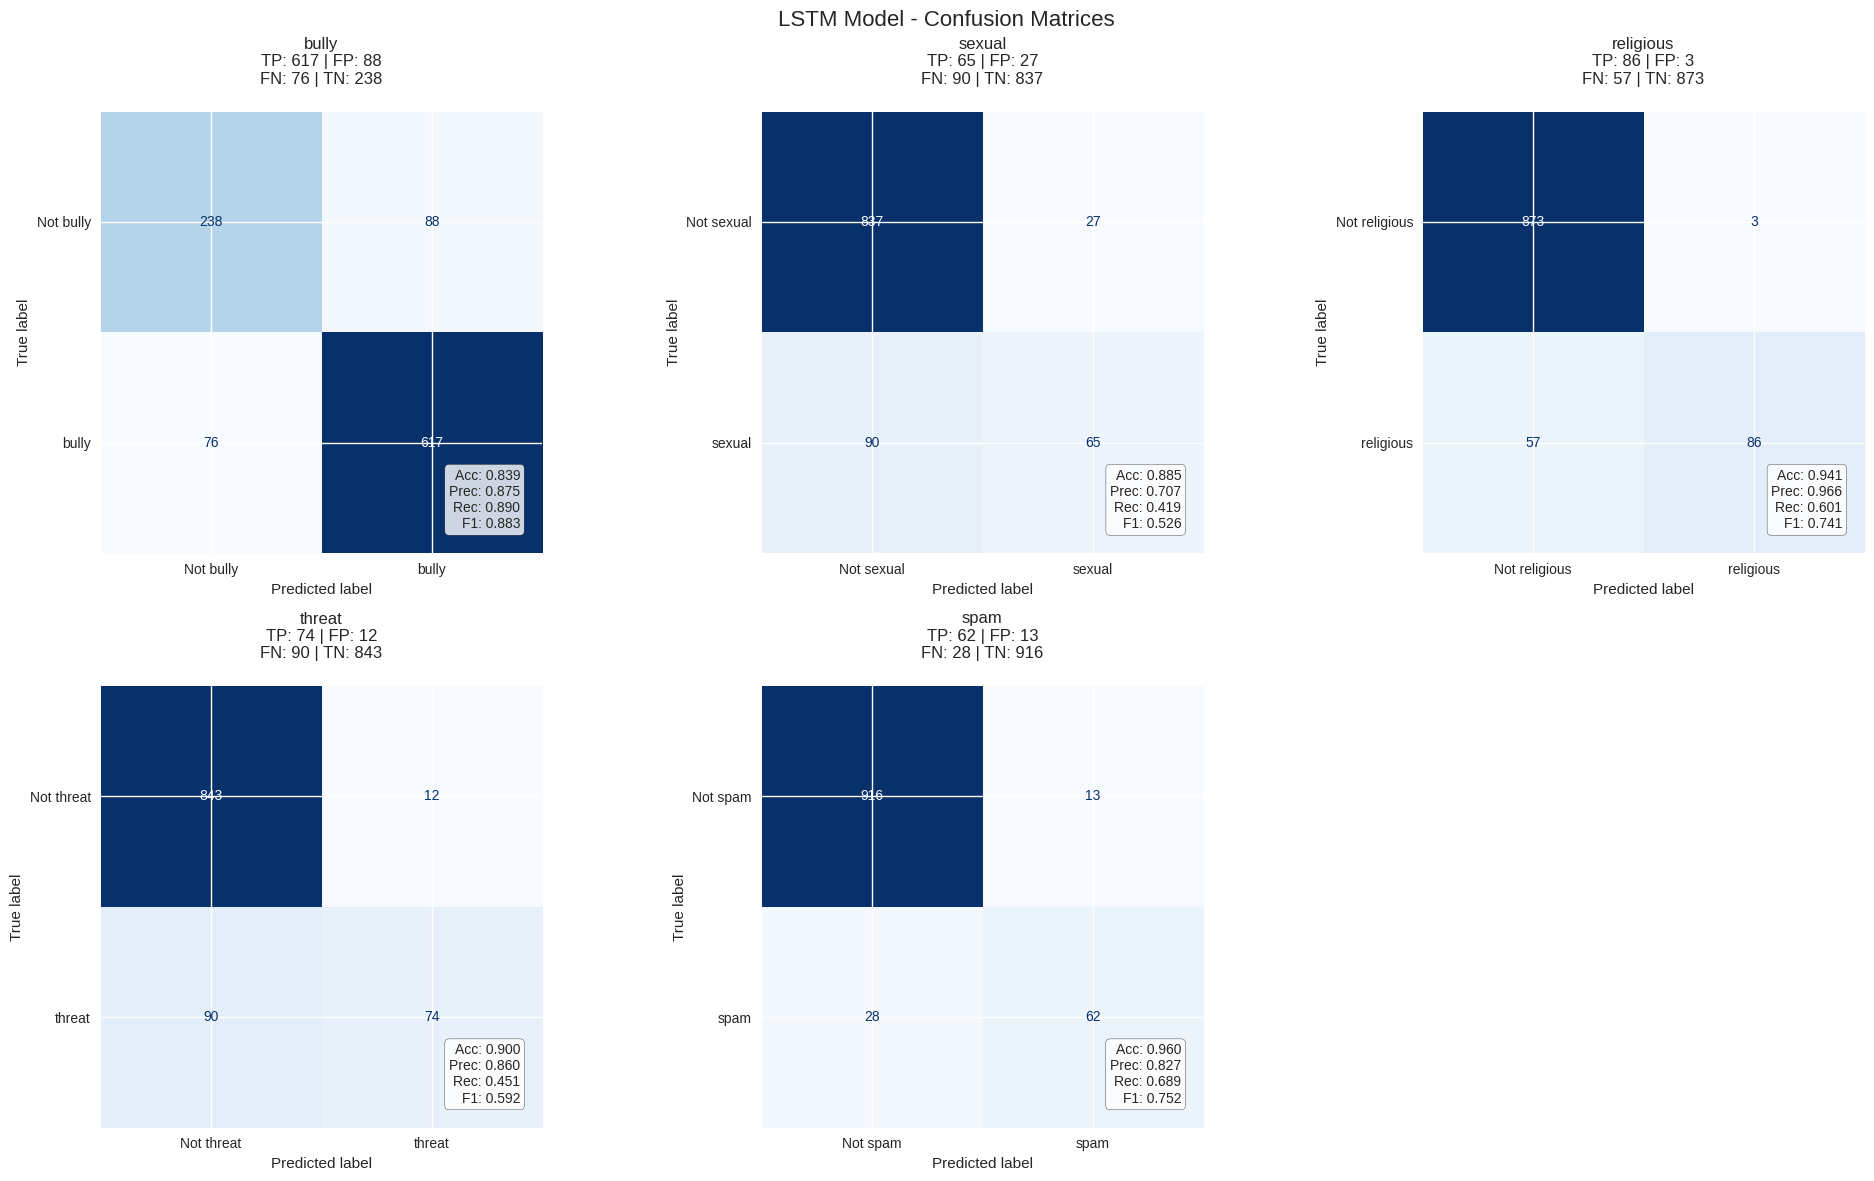

In [127]:
# Add this import at the top
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay

# ========================
# CONFUSION MATRIX SECTION 
# ========================

print(f"\n{'='*50}")
print("COMPREHENSIVE CONFUSION MATRIX")
print(f"{'='*50}")

# Create multilabel confusion matrix
mcm = multilabel_confusion_matrix(test_labels, test_preds)

# Plot a single comprehensive figure
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for i, (label, cm) in enumerate(zip(label_cols, mcm)):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not '+label, label])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f'{label}\nTP: {cm[1,1]} | FP: {cm[0,1]}\nFN: {cm[1,0]} | TN: {cm[0,0]}', 
                     fontsize=12, pad=20)
    
    # Calculate metrics
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    
    # Add metrics as text
    metrics_text = f'Acc: {accuracy:.3f}\nPrec: {precision:.3f}\nRec: {recall:.3f}\nF1: {f1:.3f}'
    axes[i].text(0.95, 0.05, metrics_text, transform=axes[i].transAxes, 
                verticalalignment='bottom', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                fontsize=10)

# Hide the last subplot if we have odd number of labels
if len(label_cols) < len(axes):
    for i in range(len(label_cols), len(axes)):
        axes[i].set_visible(False)

plt.suptitle('LSTM Model - Confusion Matrices', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()



In [128]:
# ========================
# 11. SAMPLE PREDICTIONS - LSTMOnly
# ========================

def predict_cyberbullying_lstm(text, model, vocab, device, threshold=0.5):
    """Predict cyberbullying categories for a single text using LSTM model"""
    model.eval()
    
    # Tokenize and convert to indices
    tokens = text.split()[:MAX_LEN]
    input_ids = [vocab.get(token, vocab['<UNK>']) for token in tokens]
    
    # Padding
    if len(input_ids) < MAX_LEN:
        input_ids = input_ids + [vocab['<PAD>']] * (MAX_LEN - len(input_ids))
    else:
        input_ids = input_ids[:MAX_LEN]
    
    input_ids = torch.tensor(input_ids, dtype=torch.long).unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = model(input_ids)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
        preds = (probs > threshold).astype(int)
    
    results = {label: {'prediction': int(pred), 'probability': float(prob)} 
               for label, pred, prob in zip(label_cols, preds, probs)}
    
    return results

# Display 3 sample predictions from test data
print(f"\n{'='*50}")
print("SAMPLE PREDICTIONS FROM TEST DATA - LSTM")
print(f"{'='*50}")

# Get 3 random samples from test set
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 3, replace=False)

for i, idx in enumerate(sample_indices, 1):
    sample_text = X_test[idx]
    true_labels = y_test[idx]
    
    print(f"\nSample {i}:")
    print(f"Text: {sample_text}")
    
    # Get predictions
    predictions = predict_cyberbullying_lstm(sample_text, model, vocab, device)
    
    print("Predictions:")
    for label in label_cols:
        pred = predictions[label]['prediction']
        prob = predictions[label]['probability']
        true = int(true_labels[label_cols.index(label)])
        
        status = "✓" if pred == true else "✗"
        print(f"  {label}: Pred={pred} (prob: {prob:.3f}), True={true}")


SAMPLE PREDICTIONS FROM TEST DATA - LSTM

Sample 1:
Text: চলচ্চিত্র জগতে জাহিদের কি অবদান আরেকজনকে কিভাবে অপমান করে তাকে জুতাপেটা করা দরকার
Predictions:
  bully: Pred=1 (prob: 1.000), True=1
  sexual: Pred=0 (prob: 0.000), True=0
  religious: Pred=0 (prob: 0.000), True=0
  threat: Pred=0 (prob: 0.001), True=1
  spam: Pred=0 (prob: 0.000), True=0

Sample 2:
Text: সবার সাপোর্ট চাই ভাই আইডিটা ফিরিয়ে গেছেএকটু সাপোর্ট কইরা দিয়েন
Predictions:
  bully: Pred=0 (prob: 0.000), True=0
  sexual: Pred=0 (prob: 0.000), True=0
  religious: Pred=0 (prob: 0.000), True=0
  threat: Pred=0 (prob: 0.000), True=0
  spam: Pred=1 (prob: 0.896), True=1

Sample 3:
Text: দুধটা খুইলা একটু ভালো করে করলা একটু মজা লাগবে
Predictions:
  bully: Pred=1 (prob: 1.000), True=1
  sexual: Pred=0 (prob: 0.010), True=1
  religious: Pred=0 (prob: 0.000), True=0
  threat: Pred=0 (prob: 0.000), True=0
  spam: Pred=0 (prob: 0.000), True=0


# ===================== END ======================

# Bi-LSTM

In [129]:

class BiLSTMOnly(nn.Module):
    def __init__(self, vocab_size, embedding_dim=300, hidden_dim=256, num_layers=2, 
                 num_labels=5, dropout=0.3, padding_idx=0):
        super(BiLSTMOnly, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_labels)
        
    def forward(self, input_ids, attention_mask=None):
        # input_ids shape: (batch_size, seq_length)
        embeddings = self.embedding(input_ids)  # (batch_size, seq_length, embedding_dim)
        
        lstm_output, (hidden, cell) = self.lstm(embeddings)
        # Concatenate last hidden states from both directions
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        
        hidden = self.dropout(hidden)
        logits = self.classifier(hidden)
        return logits

In [130]:
class LSTMDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=64):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab  # This should be a dictionary
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Simple tokenization (split by space)
        tokens = text.split()[:self.max_len]
        
        # Convert tokens to indices - FIXED: directly access vocab dictionary
        input_ids = []
        for token in tokens:
            if token in self.vocab:
                input_ids.append(self.vocab[token])
            else:
                input_ids.append(self.vocab['<UNK>'])
        
        # Padding
        if len(input_ids) < self.max_len:
            input_ids = input_ids + [self.vocab['<PAD>']] * (self.max_len - len(input_ids))
        else:
            input_ids = input_ids[:self.max_len]
        
        attention_mask = [1 if token != self.vocab['<PAD>'] else 0 for token in input_ids]
        
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'labels': torch.tensor(label, dtype=torch.float)
        }

In [131]:
def build_vocab(texts, min_freq=2):
    vocab = {'<PAD>': 0, '<UNK>': 1}
    word_freq = {}
    
    # Count word frequencies
    for text in texts:
        tokens = str(text).split()
        for token in tokens:
            word_freq[token] = word_freq.get(token, 0) + 1
    
    # Add words to vocabulary based on frequency
    idx = 2
    for word, freq in word_freq.items():
        if freq >= min_freq:
            vocab[word] = idx
            idx += 1
    
    return vocab

In [132]:
# Build vocabulary
print("Building vocabulary...")
vocab = build_vocab(X_train)
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")

Building vocabulary...
Vocabulary size: 9718


In [133]:
# Create datasets
train_dataset = LSTMDataset(X_train, y_train, vocab, MAX_LEN)
val_dataset = LSTMDataset(X_val, y_val, vocab, MAX_LEN)
test_dataset = LSTMDataset(X_test, y_test, vocab, MAX_LEN)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Initialize BiLSTM-only model
model = BiLSTMOnly(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=LSTM_LAYERS,
    num_labels=len(label_cols)
).to(device)

print(f"\nModel: BiLSTMOnly")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")



Model: BiLSTMOnly
Total parameters: 5,637,709


In [134]:
# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)


In [135]:
def train_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    progress_bar = tqdm(dataloader, desc='Training')
    
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        logits = model(input_ids, attention_mask)
        loss = nn.BCEWithLogitsLoss()(logits, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        
        # Calculate accuracy
        preds = torch.sigmoid(logits) > 0.5
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        progress_bar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    
    return avg_loss, accuracy

def eval_epoch(model, dataloader, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    progress_bar = tqdm(dataloader, desc='Validation')
    
    with torch.no_grad():
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            logits = model(input_ids, attention_mask)
            loss = nn.BCEWithLogitsLoss()(logits, labels)
            
            total_loss += loss.item()
            
            probs = torch.sigmoid(logits)
            preds = probs > 0.5
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
            progress_bar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    
    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels), np.array(all_probs)


In [136]:
# ========================
# 3. TRAINING LOOP - BiLSTMOnly
# ========================

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\n" + "="*50)
print("STARTING TRAINING - BiLSTMOnly")
print("="*50)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 50)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    
    # Validate
    val_loss, val_acc, _, _, _ = eval_epoch(model, val_loader, device)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Save last model checkpoint (not best)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'vocab': vocab,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_acc': train_acc,
        'val_acc': val_acc
    }, 'last_model_checkpoint_bilstm_only.pt')
    print(f"✓ Last BiLSTMOnly model checkpoint saved! (Epoch {epoch+1})")

print("\n" + "="*50)
print("TRAINING COMPLETED - BiLSTMOnly")
print("="*50)

# Print final training and validation metrics
print(f"\nFINAL TRAINING METRICS - BiLSTM:")
print(f"Last Train Loss: {history['train_loss'][-1]:.4f}")
print(f"Last Train Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Last Validation Loss: {history['val_loss'][-1]:.4f}")
print(f"Last Validation Accuracy: {history['val_acc'][-1]:.4f}")


STARTING TRAINING - BiLSTMOnly

Epoch 1/10
--------------------------------------------------


Training:   0%|          | 0/802 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.3006 | Train Acc: 0.8665
Val Loss: 0.3996 | Val Acc: 0.8844
✓ Last BiLSTMOnly model checkpoint saved! (Epoch 1)

Epoch 2/10
--------------------------------------------------


Training:   0%|          | 0/802 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.0103 | Train Acc: 0.9958
Val Loss: 0.5616 | Val Acc: 0.9054
✓ Last BiLSTMOnly model checkpoint saved! (Epoch 9)

Epoch 10/10
--------------------------------------------------


Training:   0%|          | 0/802 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.0091 | Train Acc: 0.9962
Val Loss: 0.6052 | Val Acc: 0.9046
✓ Last BiLSTMOnly model checkpoint saved! (Epoch 10)

TRAINING COMPLETED - BiLSTMOnly

FINAL TRAINING METRICS - BiLSTM:
Last Train Loss: 0.0091
Last Train Accuracy: 0.9962
Last Validation Loss: 0.6052
Last Validation Accuracy: 0.9046


In [137]:
# ========================
# 7. TEST EVALUATION - BiLSTMOnly
# ========================

print("\n" + "="*50)
print("TESTING WITH LAST BiLSTM MODEL")
print("="*50)

# # Load last model checkpoint
# checkpoint = torch.load('last_model_checkpoint_bilstm_only.pt')
# model.load_state_dict(checkpoint['model_state_dict'])

# Evaluate on test set
test_loss, test_acc, test_preds, test_labels, test_probs = eval_epoch(model, test_loader, device)

print(f"\n{'='*50}")
print(f"TEST RESULTS - BiLSTM")
print(f"{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Hamming Loss: {hamming_loss(test_labels, test_preds):.4f}")


TESTING WITH LAST BiLSTM MODEL


Validation:   0%|          | 0/32 [00:00<?, ?it/s]


TEST RESULTS - BiLSTM
Test Loss: 0.5943
Test Accuracy: 0.9048
Hamming Loss: 0.0952


In [138]:
# Calculate precision, recall, F1 scores
precision = precision_score(test_labels, test_preds, average='micro', zero_division=0)
recall = recall_score(test_labels, test_preds, average='micro', zero_division=0)
f1 = f1_score(test_labels, test_preds, average='micro', zero_division=0)

print(f"\nOverall Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Overall Metrics:
Precision: 0.8640
Recall: 0.7245
F1-Score: 0.7881


In [139]:
# Per-label metrics
print(f"\n{'='*50}")
print("PER-LABEL CLASSIFICATION REPORT - BiLSTMOnly")
print(f"{'='*50}")
print(classification_report(
    test_labels, 
    test_preds, 
    target_names=label_cols,
    zero_division=0
))



PER-LABEL CLASSIFICATION REPORT - BiLSTMOnly
              precision    recall  f1-score   support

       bully       0.89      0.90      0.89       693
      sexual       0.69      0.41      0.52       155
   religious       0.93      0.54      0.68       143
      threat       0.86      0.46      0.60       164
        spam       0.81      0.70      0.75        90

   micro avg       0.86      0.72      0.79      1245
   macro avg       0.83      0.60      0.69      1245
weighted avg       0.86      0.72      0.77      1245
 samples avg       0.69      0.62      0.64      1245



In [140]:

# ========================
# MCC AND COHEN'S KAPPA SCORES
# ========================

from sklearn.metrics import matthews_corrcoef, cohen_kappa_score
import numpy as np

# Convert to numpy arrays
test_labels_np = np.array(test_labels)
test_preds_np = np.array(test_preds)

class_names = ['bully', 'sexual', 'religious', 'threat', 'spam']

print(f"\n{'='*50}")
print(f"MCC AND COHEN'S KAPPA SCORES")
print(f"{'='*50}")

# Calculate for each class
mcc_scores = []
kappa_scores = []

print("\nPer-class Scores:")
for i, class_name in enumerate(class_names):
    mcc = matthews_corrcoef(test_labels_np[:, i], test_preds_np[:, i])
    kappa = cohen_kappa_score(test_labels_np[:, i], test_preds_np[:, i])
    
    mcc_scores.append(mcc)
    kappa_scores.append(kappa)
    
    print(f"{class_name:>10}: MCC = {mcc:.4f}, Cohen's Kappa = {kappa:.4f}")

# Calculate averages
average_mcc = np.mean(mcc_scores)
average_kappa = np.mean(kappa_scores)

print(f"\nAverage Scores:")
print(f"MCC: {average_mcc:.4f}")
print(f"Cohen's Kappa: {average_kappa:.4f}")


MCC AND COHEN'S KAPPA SCORES

Per-class Scores:
     bully: MCC = 0.6591, Cohen's Kappa = 0.6589
    sexual: MCC = 0.4730, Cohen's Kappa = 0.4538
 religious: MCC = 0.6751, Cohen's Kappa = 0.6448
    threat: MCC = 0.5829, Cohen's Kappa = 0.5471
      spam: MCC = 0.7299, Cohen's Kappa = 0.7277

Average Scores:
MCC: 0.6240
Cohen's Kappa: 0.6065


In [141]:
# Calculate AUC-ROC for each class
print(f"\n{'='*50}")
print("AUC-ROC SCORES FOR EACH CLASS - BiLSTM")
print(f"{'='*50}")
for i, label in enumerate(label_cols):
    try:
        auc = roc_auc_score(test_labels[:, i], test_probs[:, i])
        print(f"{label}: {auc:.4f}")
    except ValueError:
        print(f"{label}: Could not calculate AUC (only one class present)")

# Calculate overall micro and macro AUC
try:
    micro_auc = roc_auc_score(test_labels, test_probs, average='micro')
    macro_auc = roc_auc_score(test_labels, test_probs, average='macro')
    print(f"\nMicro AUC: {micro_auc:.4f}")
    print(f"Macro AUC: {macro_auc:.4f}")
except ValueError:
    print("\nCould not calculate overall AUC scores")



AUC-ROC SCORES FOR EACH CLASS - BiLSTM
bully: 0.9022
sexual: 0.8303
religious: 0.9079
threat: 0.8951
spam: 0.9420

Micro AUC: 0.9354
Macro AUC: 0.8955


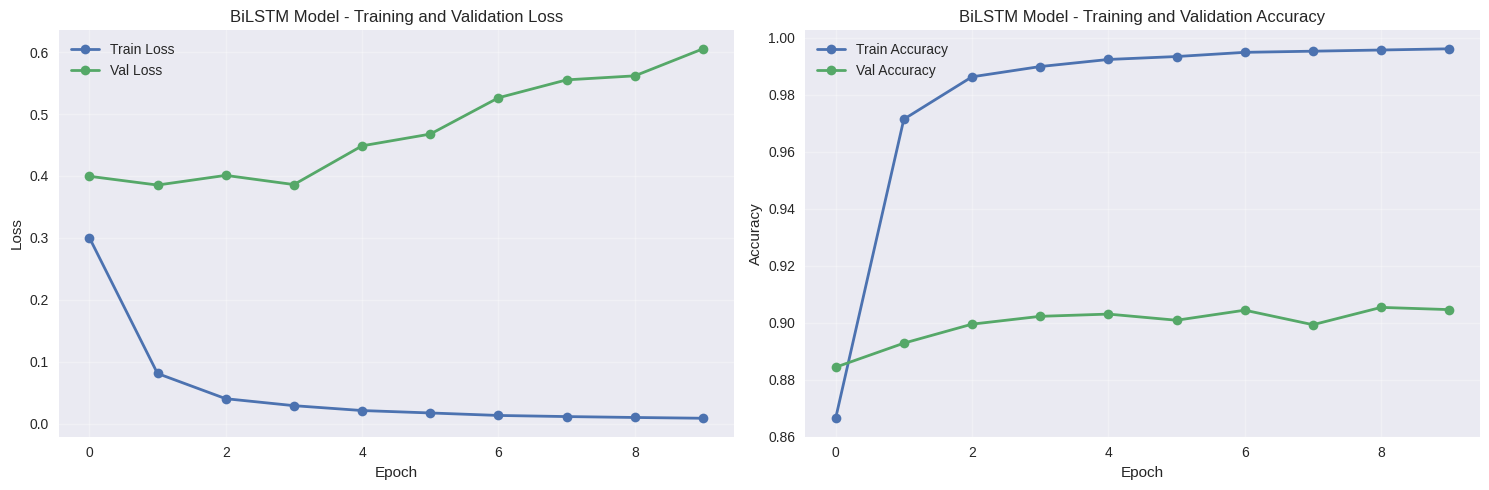

In [142]:
# ========================
# 8. PLOT TRAINING HISTORY - BiLSTMOnly
# ========================

plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', marker='o', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('BiLSTM Model - Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='o', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('BiLSTM Model - Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('BiLSTMOnly_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

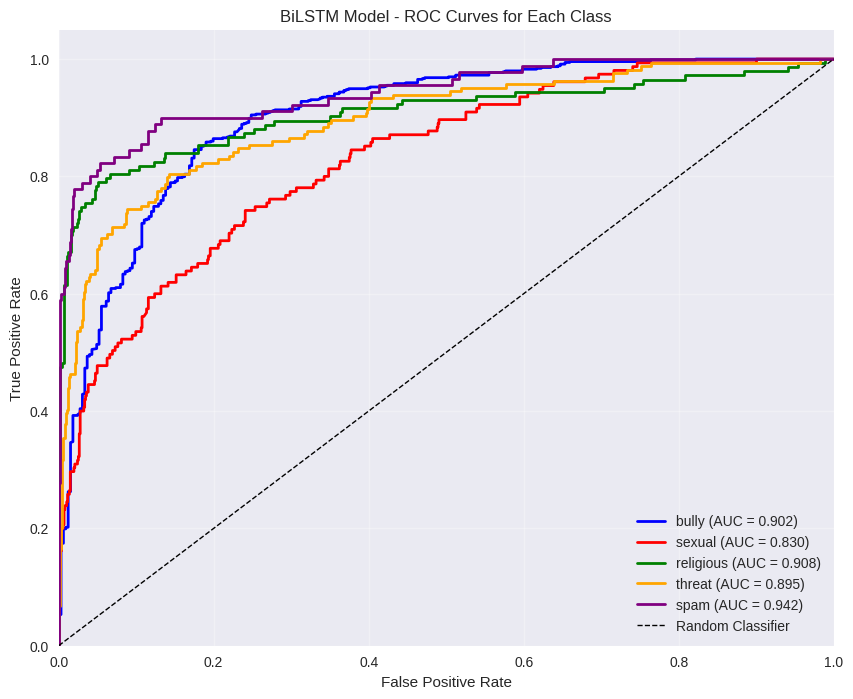

In [143]:
# ========================
# 9. PLOT ROC CURVES - BiLSTMOnly
# ========================

# Plot ROC curves for each class
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple']

for i, label in enumerate(label_cols):
    try:
        fpr, tpr, _ = roc_curve(test_labels[:, i], test_probs[:, i])
        auc = roc_auc_score(test_labels[:, i], test_probs[:, i])
        plt.plot(fpr, tpr, color=colors[i], linewidth=2, 
                label=f'{label} (AUC = {auc:.3f})')
    except ValueError:
        continue

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('BiLSTM Model - ROC Curves for Each Class')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('BiLSTMOnly_ROC_curves.png', dpi=300, bbox_inches='tight')
plt.show()


COMPREHENSIVE CONFUSION MATRIX


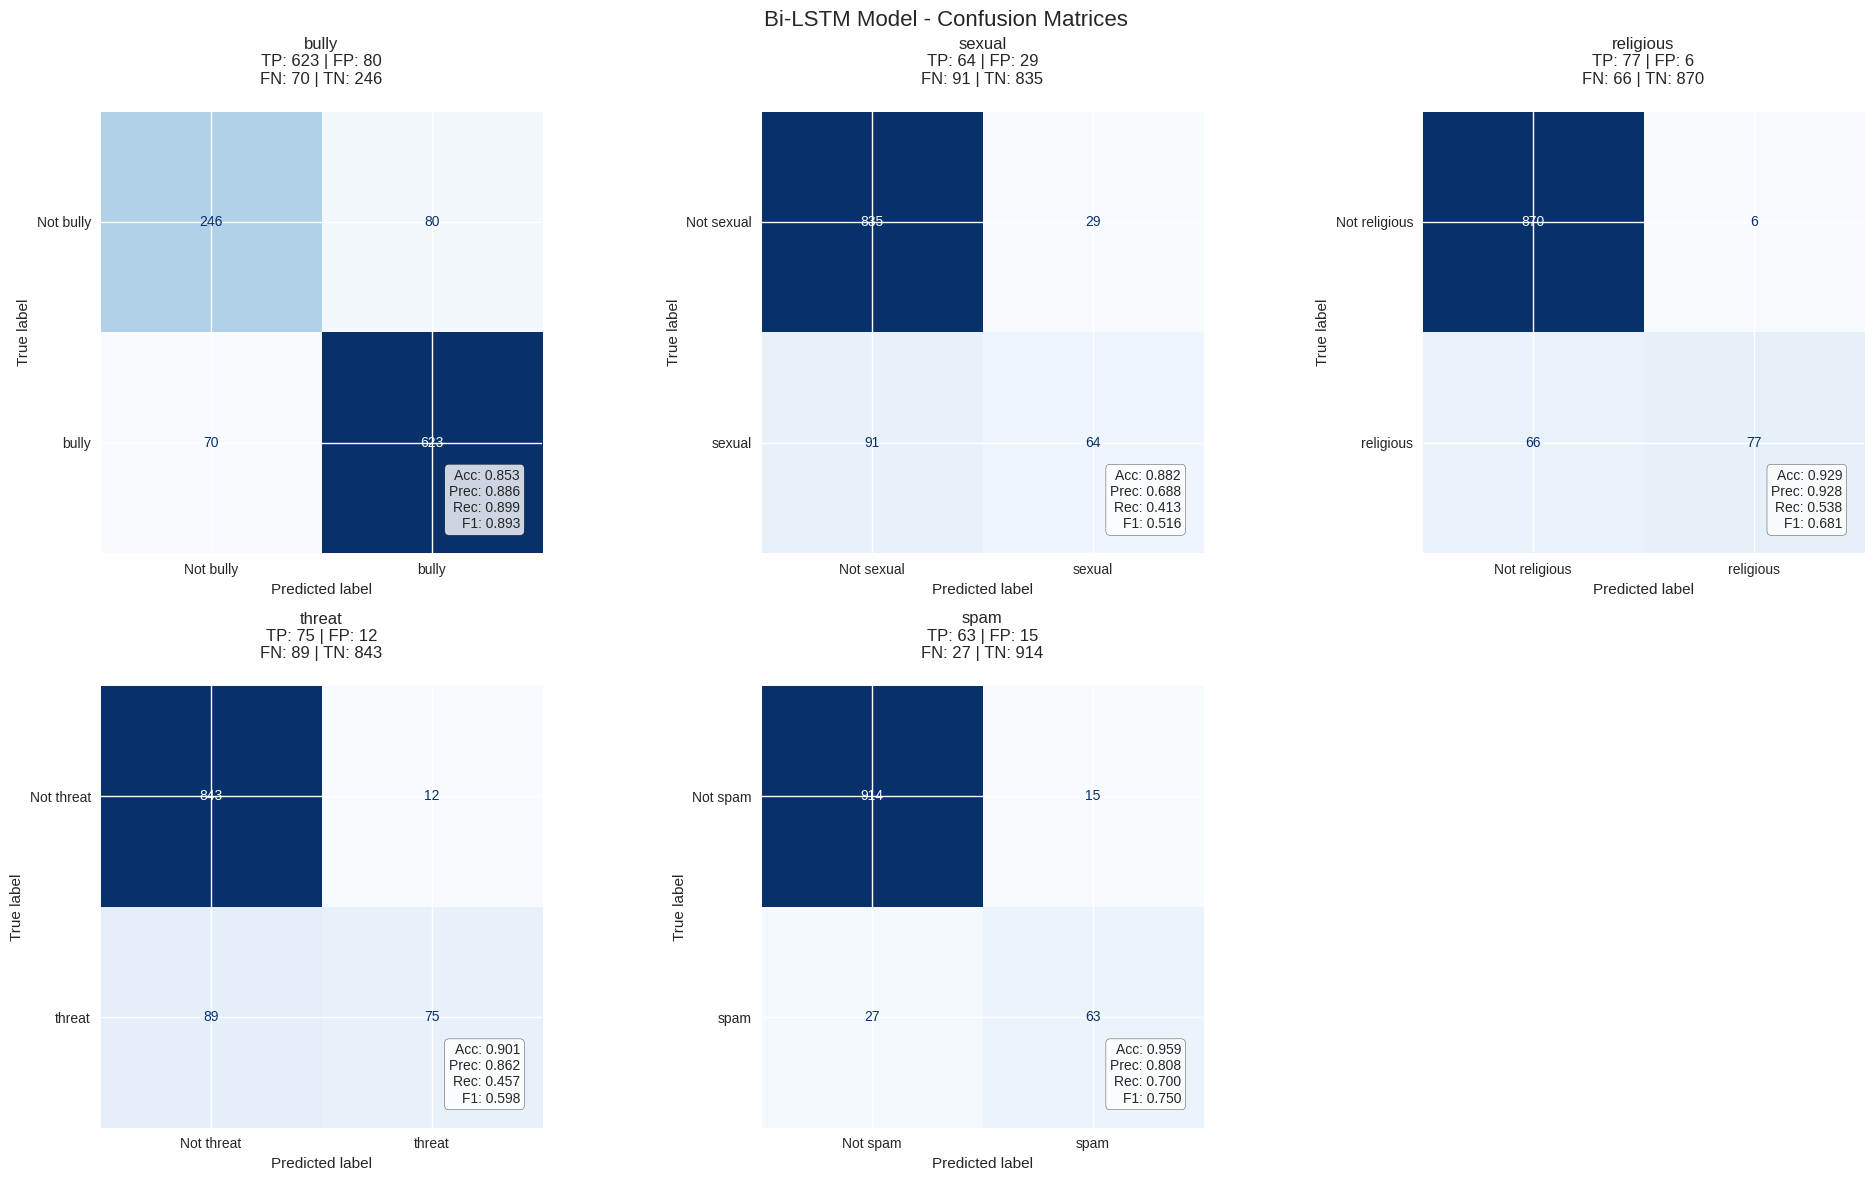

In [144]:
# Add this import at the top
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay

# ========================
# CONFUSION MATRIX SECTION 
# ========================

print(f"\n{'='*50}")
print("COMPREHENSIVE CONFUSION MATRIX")
print(f"{'='*50}")

# Create multilabel confusion matrix
mcm = multilabel_confusion_matrix(test_labels, test_preds)

# Plot a single comprehensive figure
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for i, (label, cm) in enumerate(zip(label_cols, mcm)):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not '+label, label])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f'{label}\nTP: {cm[1,1]} | FP: {cm[0,1]}\nFN: {cm[1,0]} | TN: {cm[0,0]}', 
                     fontsize=12, pad=20)
    
    # Calculate metrics
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    
    # Add metrics as text
    metrics_text = f'Acc: {accuracy:.3f}\nPrec: {precision:.3f}\nRec: {recall:.3f}\nF1: {f1:.3f}'
    axes[i].text(0.95, 0.05, metrics_text, transform=axes[i].transAxes, 
                verticalalignment='bottom', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                fontsize=10)

# Hide the last subplot if we have odd number of labels
if len(label_cols) < len(axes):
    for i in range(len(label_cols), len(axes)):
        axes[i].set_visible(False)

plt.suptitle('Bi-LSTM Model - Confusion Matrices', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()



In [145]:
# ========================
# 10. SAMPLE PREDICTIONS - BiLSTMOnly
# ========================

def predict_cyberbullying_bilstm(text, model, vocab, device, threshold=0.5):
    """Predict cyberbullying categories for a single text using BiLSTM model"""
    model.eval()
    
    # Tokenize and convert to indices
    tokens = text.split()[:MAX_LEN]
    input_ids = [vocab.get(token, vocab['<UNK>']) for token in tokens]
    
    # Padding
    if len(input_ids) < MAX_LEN:
        input_ids = input_ids + [vocab['<PAD>']] * (MAX_LEN - len(input_ids))
    else:
        input_ids = input_ids[:MAX_LEN]
    
    input_ids = torch.tensor(input_ids, dtype=torch.long).unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = model(input_ids)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
        preds = (probs > threshold).astype(int)
    
    results = {label: {'prediction': int(pred), 'probability': float(prob)} 
               for label, pred, prob in zip(label_cols, preds, probs)}
    
    return results

# Display 3 sample predictions from test data
print(f"\n{'='*50}")
print("SAMPLE PREDICTIONS FROM TEST DATA - BiLSTM")
print(f"{'='*50}")

# Get 3 random samples from test set
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 3, replace=False)

for i, idx in enumerate(sample_indices, 1):
    sample_text = X_test[idx]
    true_labels = y_test[idx]
    
    print(f"\nSample {i}:")
    print(f"Text: {sample_text}")
    
    # Get predictions
    predictions = predict_cyberbullying_bilstm(sample_text, model, vocab, device)
    
    print("Predictions:")
    for label in label_cols:
        pred = predictions[label]['prediction']
        prob = predictions[label]['probability']
        true = int(true_labels[label_cols.index(label)])
        
        status = "✓" if pred == true else "✗"
        print(f"  {label}: Pred={pred} (prob: {prob:.3f}), True={true}")


SAMPLE PREDICTIONS FROM TEST DATA - BiLSTM

Sample 1:
Text: চলচ্চিত্র জগতে জাহিদের কি অবদান আরেকজনকে কিভাবে অপমান করে তাকে জুতাপেটা করা দরকার
Predictions:
  bully: Pred=1 (prob: 1.000), True=1
  sexual: Pred=0 (prob: 0.000), True=0
  religious: Pred=0 (prob: 0.000), True=0
  threat: Pred=1 (prob: 0.584), True=1
  spam: Pred=0 (prob: 0.000), True=0

Sample 2:
Text: সবার সাপোর্ট চাই ভাই আইডিটা ফিরিয়ে গেছেএকটু সাপোর্ট কইরা দিয়েন
Predictions:
  bully: Pred=0 (prob: 0.000), True=0
  sexual: Pred=0 (prob: 0.000), True=0
  religious: Pred=0 (prob: 0.000), True=0
  threat: Pred=0 (prob: 0.000), True=0
  spam: Pred=1 (prob: 1.000), True=1

Sample 3:
Text: দুধটা খুইলা একটু ভালো করে করলা একটু মজা লাগবে
Predictions:
  bully: Pred=1 (prob: 0.998), True=1
  sexual: Pred=0 (prob: 0.001), True=1
  religious: Pred=0 (prob: 0.000), True=0
  threat: Pred=0 (prob: 0.000), True=0
  spam: Pred=0 (prob: 0.000), True=0


# ================== END ==========================

# ================ GRU ==========================

In [146]:
# ========================
# 3. MODEL ARCHITECTURE: GRU
# ========================

class GRU(nn.Module):
    def __init__(self, vocab_size, embedding_dim=300, hidden_dim=256, num_layers=2, 
                 num_labels=5, dropout=0.3, padding_idx=0):
        super(GRU, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        self.gru = nn.GRU(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_labels)
        
    def forward(self, input_ids, attention_mask=None):
        # input_ids shape: (batch_size, seq_length)
        embeddings = self.embedding(input_ids)  # (batch_size, seq_length, embedding_dim)
        
        gru_output, hidden = self.gru(embeddings)
        # Concatenate last hidden states from both directions
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        
        hidden = self.dropout(hidden)
        logits = self.classifier(hidden)
        return logits

In [147]:
# ========================
# 4. DATA PREPARATION FOR GRU
# ========================

class LSTMDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=64):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab  # This should be a dictionary
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Simple tokenization (split by space)
        tokens = text.split()[:self.max_len]
        
        # Convert tokens to indices - FIXED: directly access vocab dictionary
        input_ids = []
        for token in tokens:
            if token in self.vocab:
                input_ids.append(self.vocab[token])
            else:
                input_ids.append(self.vocab['<UNK>'])
        
        # Padding
        if len(input_ids) < self.max_len:
            input_ids = input_ids + [self.vocab['<PAD>']] * (self.max_len - len(input_ids))
        else:
            input_ids = input_ids[:self.max_len]
        
        attention_mask = [1 if token != self.vocab['<PAD>'] else 0 for token in input_ids]
        
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'labels': torch.tensor(label, dtype=torch.float)
        }

In [148]:
def build_vocab(texts, min_freq=2):
    vocab = {'<PAD>': 0, '<UNK>': 1}
    word_freq = {}
    
    # Count word frequencies
    for text in texts:
        tokens = str(text).split()
        for token in tokens:
            word_freq[token] = word_freq.get(token, 0) + 1
    
    # Add words to vocabulary based on frequency
    idx = 2
    for word, freq in word_freq.items():
        if freq >= min_freq:
            vocab[word] = idx
            idx += 1
    
    return vocab

In [149]:
# ========================
# 5. MAIN TRAINING PIPELINE - GRU
# ========================

# Configuration
MAX_LEN = 64
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-3
EMBEDDING_DIM = 300
HIDDEN_DIM = 256
GRU_LAYERS = 2

# Build vocabulary from training data
print("Building vocabulary...")
vocab = build_vocab(X_train)
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")

# Create datasets
train_dataset = LSTMDataset(X_train, y_train, vocab, MAX_LEN)
val_dataset = LSTMDataset(X_val, y_val, vocab, MAX_LEN)
test_dataset = LSTMDataset(X_test, y_test, vocab, MAX_LEN)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Initialize GRU model
model = GRU(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=GRU_LAYERS,
    num_labels=len(label_cols)
).to(device)

print(f"\nModel: GRU")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Building vocabulary...
Vocabulary size: 9718

Model: GRU
Total parameters: 4,957,773


In [150]:
# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)


In [151]:

def train_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    progress_bar = tqdm(dataloader, desc='Training')
    
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        logits = model(input_ids, attention_mask)
        loss = nn.BCEWithLogitsLoss()(logits, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        
        # Calculate accuracy
        preds = torch.sigmoid(logits) > 0.5
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        progress_bar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    
    return avg_loss, accuracy

def eval_epoch(model, dataloader, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    progress_bar = tqdm(dataloader, desc='Validation')
    
    with torch.no_grad():
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            logits = model(input_ids, attention_mask)
            loss = nn.BCEWithLogitsLoss()(logits, labels)
            
            total_loss += loss.item()
            
            probs = torch.sigmoid(logits)
            preds = probs > 0.5
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
            progress_bar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    
    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels), np.array(all_probs)

In [152]:
# ========================
# 6. TRAINING LOOP - GRU
# ========================

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\n" + "="*50)
print("STARTING TRAINING - GRU")
print("="*50)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 50)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    
    # Validate
    val_loss, val_acc, _, _, _ = eval_epoch(model, val_loader, device)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Save last model checkpoint (not best)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'vocab': vocab,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_acc': train_acc,
        'val_acc': val_acc
    }, 'last_model_checkpoint_gru.pt')
    print(f"✓ Last GRU model checkpoint saved! (Epoch {epoch+1})")

print("\n" + "="*50)
print("TRAINING COMPLETED - GRU")
print("="*50)

# Print final training and validation metrics
print(f"\nFINAL TRAINING METRICS - GRU:")
print(f"Last Train Loss: {history['train_loss'][-1]:.4f}")
print(f"Last Train Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Last Validation Loss: {history['val_loss'][-1]:.4f}")
print(f"Last Validation Accuracy: {history['val_acc'][-1]:.4f}")



STARTING TRAINING - GRU

Epoch 1/10
--------------------------------------------------


Training:   0%|          | 0/802 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.2853 | Train Acc: 0.8704
Val Loss: 0.3350 | Val Acc: 0.8893
✓ Last GRU model checkpoint saved! (Epoch 1)

Epoch 2/10
--------------------------------------------------


Training:   0%|          | 0/802 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.0107 | Train Acc: 0.9958
Val Loss: 0.5003 | Val Acc: 0.9050
✓ Last GRU model checkpoint saved! (Epoch 9)

Epoch 10/10
--------------------------------------------------


Training:   0%|          | 0/802 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.0098 | Train Acc: 0.9960
Val Loss: 0.5065 | Val Acc: 0.9056
✓ Last GRU model checkpoint saved! (Epoch 10)

TRAINING COMPLETED - GRU

FINAL TRAINING METRICS - GRU:
Last Train Loss: 0.0098
Last Train Accuracy: 0.9960
Last Validation Loss: 0.5065
Last Validation Accuracy: 0.9056


In [153]:
# ========================
# 7. TEST EVALUATION - GRU
# ========================

print("\n" + "="*50)
print("TESTING WITH LAST GRU MODEL")
print("="*50)

# # Load last model checkpoint
# checkpoint = torch.load('last_model_checkpoint_gru.pt')
# model.load_state_dict(checkpoint['model_state_dict'])

# Evaluate on test set
test_loss, test_acc, test_preds, test_labels, test_probs = eval_epoch(model, test_loader, device)

print(f"\n{'='*50}")
print(f"TEST RESULTS - GRU")
print(f"{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Hamming Loss: {hamming_loss(test_labels, test_preds):.4f}")


TESTING WITH LAST GRU MODEL


Validation:   0%|          | 0/32 [00:00<?, ?it/s]


TEST RESULTS - GRU
Test Loss: 0.5120
Test Accuracy: 0.9064
Hamming Loss: 0.0936


In [154]:
# Calculate precision, recall, F1 scores
precision = precision_score(test_labels, test_preds, average='micro', zero_division=0)
recall = recall_score(test_labels, test_preds, average='micro', zero_division=0)
f1 = f1_score(test_labels, test_preds, average='micro', zero_division=0)

print(f"\nOverall Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Overall Metrics:
Precision: 0.8542
Recall: 0.7438
F1-Score: 0.7952


In [155]:

# ========================
# MCC AND COHEN'S KAPPA SCORES
# ========================

from sklearn.metrics import matthews_corrcoef, cohen_kappa_score
import numpy as np

# Convert to numpy arrays
test_labels_np = np.array(test_labels)
test_preds_np = np.array(test_preds)

class_names = ['bully', 'sexual', 'religious', 'threat', 'spam']

print(f"\n{'='*50}")
print(f"MCC AND COHEN'S KAPPA SCORES")
print(f"{'='*50}")

# Calculate for each class
mcc_scores = []
kappa_scores = []

print("\nPer-class Scores:")
for i, class_name in enumerate(class_names):
    mcc = matthews_corrcoef(test_labels_np[:, i], test_preds_np[:, i])
    kappa = cohen_kappa_score(test_labels_np[:, i], test_preds_np[:, i])
    
    mcc_scores.append(mcc)
    kappa_scores.append(kappa)
    
    print(f"{class_name:>10}: MCC = {mcc:.4f}, Cohen's Kappa = {kappa:.4f}")

# Calculate averages
average_mcc = np.mean(mcc_scores)
average_kappa = np.mean(kappa_scores)

print(f"\nAverage Scores:")
print(f"MCC: {average_mcc:.4f}")
print(f"Cohen's Kappa: {average_kappa:.4f}")


MCC AND COHEN'S KAPPA SCORES

Per-class Scores:
     bully: MCC = 0.6309, Cohen's Kappa = 0.6300
    sexual: MCC = 0.4779, Cohen's Kappa = 0.4645
 religious: MCC = 0.7690, Cohen's Kappa = 0.7534
    threat: MCC = 0.5974, Cohen's Kappa = 0.5619
      spam: MCC = 0.7169, Cohen's Kappa = 0.7147

Average Scores:
MCC: 0.6384
Cohen's Kappa: 0.6249


In [156]:
# Per-label metrics
print(f"\n{'='*50}")
print("PER-LABEL CLASSIFICATION REPORT - GRU")
print(f"{'='*50}")
print(classification_report(
    test_labels, 
    test_preds, 
    target_names=label_cols,
    zero_division=0
))



PER-LABEL CLASSIFICATION REPORT - GRU
              precision    recall  f1-score   support

       bully       0.87      0.90      0.89       693
      sexual       0.67      0.44      0.53       155
   religious       0.95      0.66      0.78       143
      threat       0.88      0.47      0.61       164
        spam       0.79      0.69      0.74        90

   micro avg       0.85      0.74      0.80      1245
   macro avg       0.83      0.63      0.71      1245
weighted avg       0.85      0.74      0.78      1245
 samples avg       0.70      0.63      0.65      1245



In [157]:
# Calculate AUC-ROC for each class
print(f"\n{'='*50}")
print("AUC-ROC SCORES FOR EACH CLASS - GRU")
print(f"{'='*50}")
for i, label in enumerate(label_cols):
    try:
        auc = roc_auc_score(test_labels[:, i], test_probs[:, i])
        print(f"{label}: {auc:.4f}")
    except ValueError:
        print(f"{label}: Could not calculate AUC (only one class present)")

# Calculate overall micro and macro AUC
try:
    micro_auc = roc_auc_score(test_labels, test_probs, average='micro')
    macro_auc = roc_auc_score(test_labels, test_probs, average='macro')
    print(f"\nMicro AUC: {micro_auc:.4f}")
    print(f"Macro AUC: {macro_auc:.4f}")
except ValueError:
    print("\nCould not calculate overall AUC scores")



AUC-ROC SCORES FOR EACH CLASS - GRU
bully: 0.9065
sexual: 0.8483
religious: 0.9181
threat: 0.8981
spam: 0.9297

Micro AUC: 0.9385
Macro AUC: 0.9001


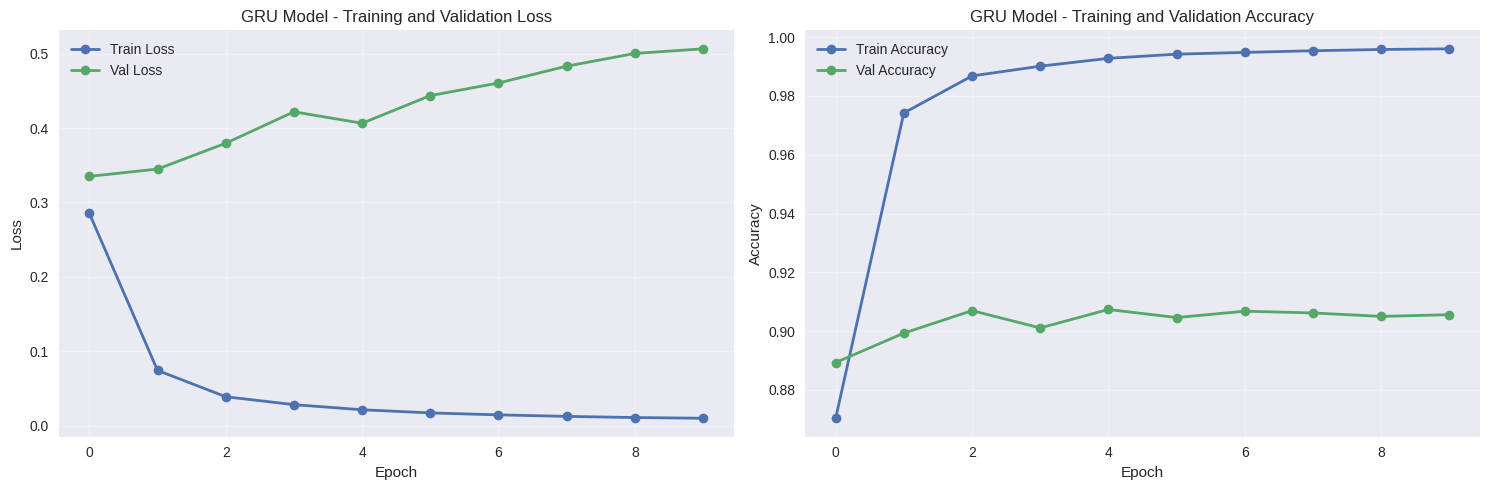

In [158]:
# ========================
# 8. PLOT TRAINING HISTORY - GRU
# ========================

plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', marker='o', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('GRU Model - Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='o', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('GRU Model - Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('GRU_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

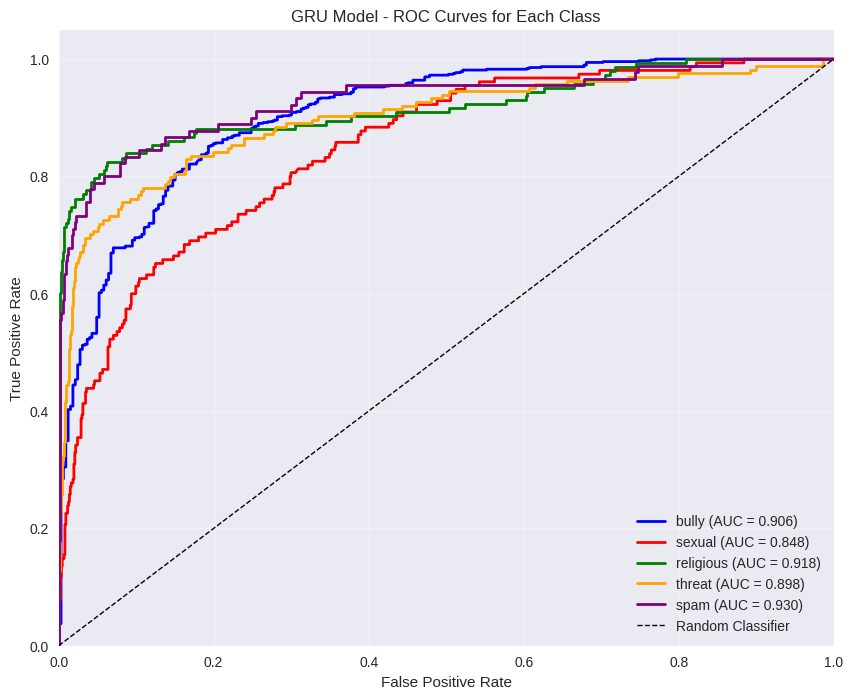

In [159]:
# ========================
# 9. PLOT ROC CURVES - GRU
# ========================

# Plot ROC curves for each class
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple']

for i, label in enumerate(label_cols):
    try:
        fpr, tpr, _ = roc_curve(test_labels[:, i], test_probs[:, i])
        auc = roc_auc_score(test_labels[:, i], test_probs[:, i])
        plt.plot(fpr, tpr, color=colors[i], linewidth=2, 
                label=f'{label} (AUC = {auc:.3f})')
    except ValueError:
        continue

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('GRU Model - ROC Curves for Each Class')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('GRU_ROC_curves.png', dpi=300, bbox_inches='tight')
plt.show()


COMPREHENSIVE CONFUSION MATRIX


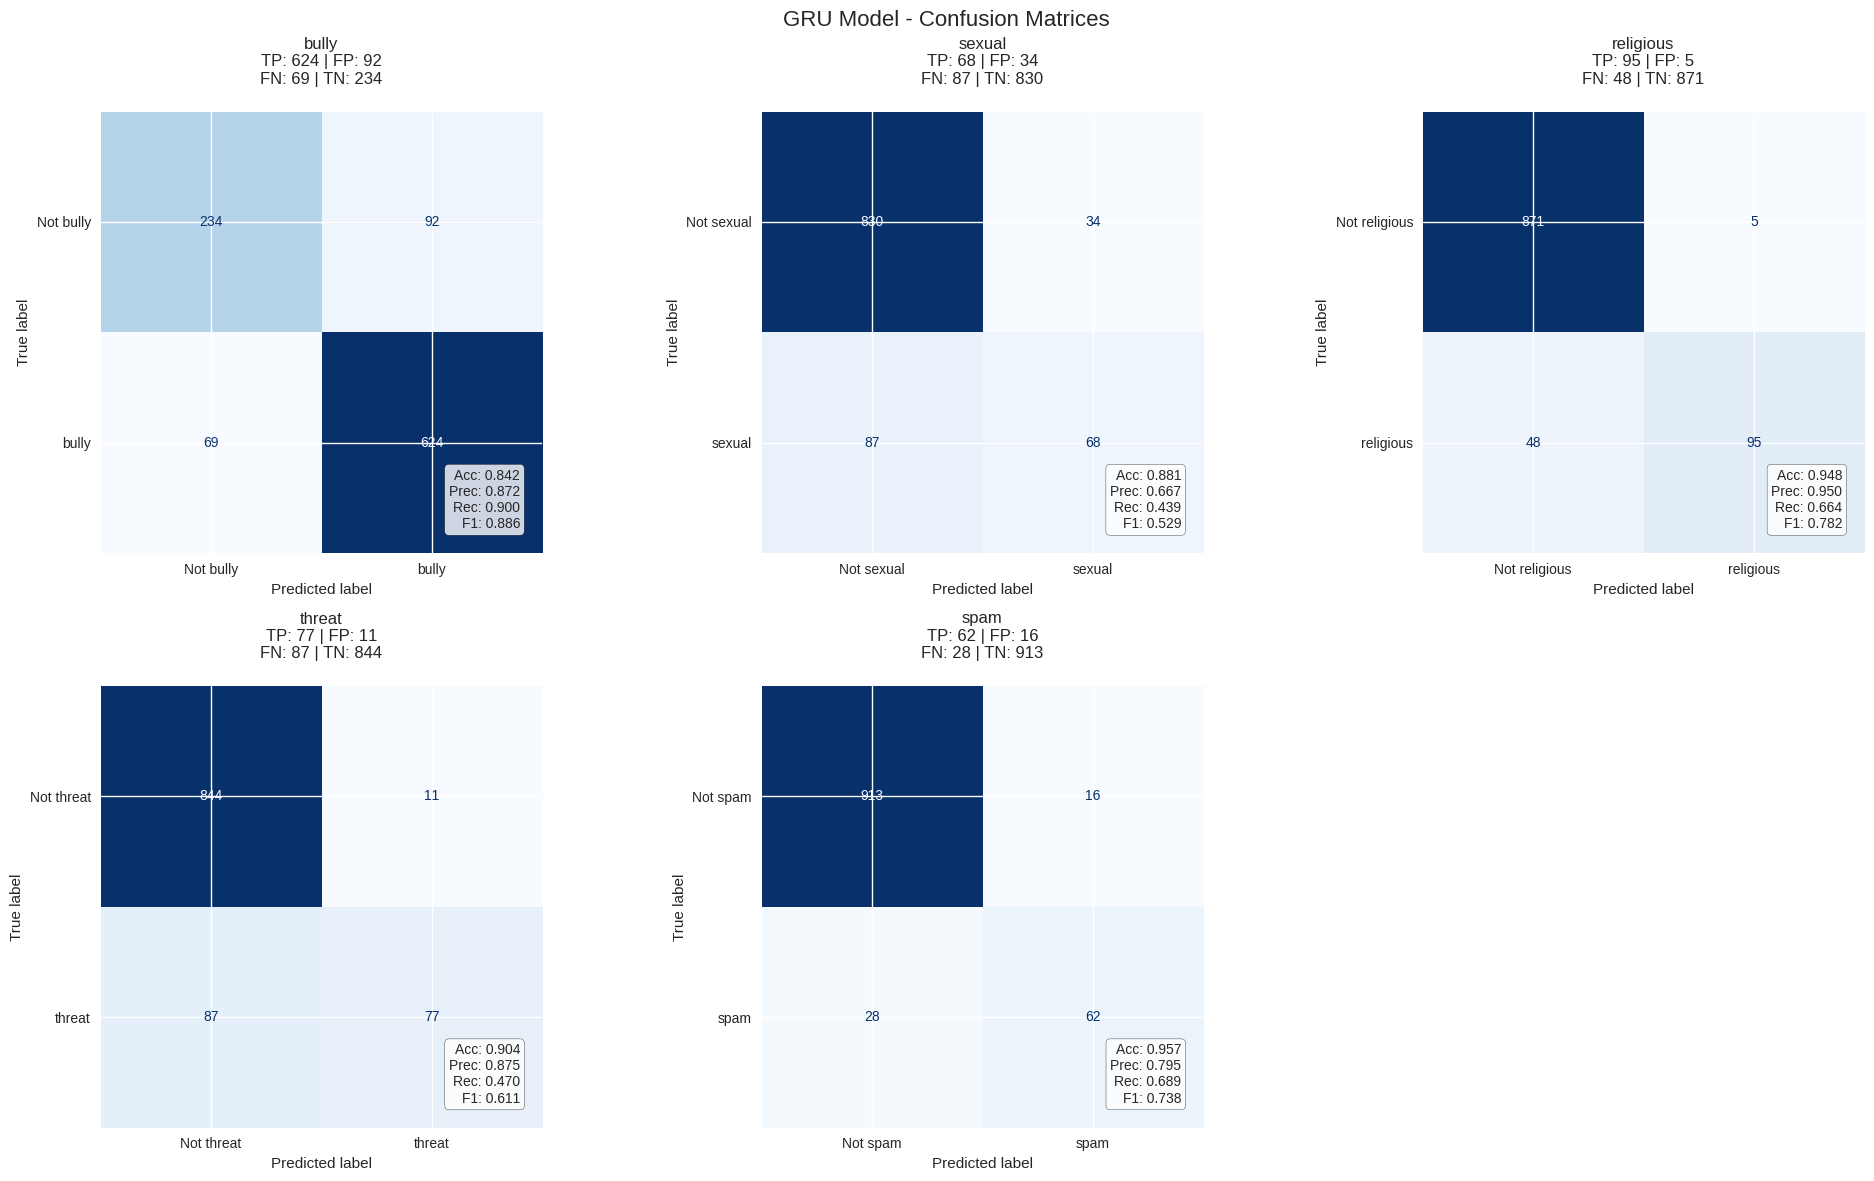

In [160]:
# Add this import at the top
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay

# ========================
# CONFUSION MATRIX SECTION 
# ========================

print(f"\n{'='*50}")
print("COMPREHENSIVE CONFUSION MATRIX")
print(f"{'='*50}")

# Create multilabel confusion matrix
mcm = multilabel_confusion_matrix(test_labels, test_preds)

# Plot a single comprehensive figure
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for i, (label, cm) in enumerate(zip(label_cols, mcm)):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not '+label, label])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f'{label}\nTP: {cm[1,1]} | FP: {cm[0,1]}\nFN: {cm[1,0]} | TN: {cm[0,0]}', 
                     fontsize=12, pad=20)
    
    # Calculate metrics
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    
    # Add metrics as text
    metrics_text = f'Acc: {accuracy:.3f}\nPrec: {precision:.3f}\nRec: {recall:.3f}\nF1: {f1:.3f}'
    axes[i].text(0.95, 0.05, metrics_text, transform=axes[i].transAxes, 
                verticalalignment='bottom', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                fontsize=10)

# Hide the last subplot if we have odd number of labels
if len(label_cols) < len(axes):
    for i in range(len(label_cols), len(axes)):
        axes[i].set_visible(False)

plt.suptitle('GRU Model - Confusion Matrices', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()



In [161]:
# ========================
# 10. SAMPLE PREDICTIONS - GRU
# ========================

def predict_cyberbullying_gru(text, model, vocab, device, threshold=0.5):
    """Predict cyberbullying categories for a single text using GRU model"""
    model.eval()
    
    # Tokenize and convert to indices
    tokens = text.split()[:MAX_LEN]
    input_ids = []
    for token in tokens:
        if token in vocab:
            input_ids.append(vocab[token])
        else:
            input_ids.append(vocab['<UNK>'])
    
    # Padding
    if len(input_ids) < MAX_LEN:
        input_ids = input_ids + [vocab['<PAD>']] * (MAX_LEN - len(input_ids))
    else:
        input_ids = input_ids[:MAX_LEN]
    
    input_ids = torch.tensor(input_ids, dtype=torch.long).unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = model(input_ids)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
        preds = (probs > threshold).astype(int)
    
    results = {label: {'prediction': int(pred), 'probability': float(prob)} 
               for label, pred, prob in zip(label_cols, preds, probs)}
    
    return results

# Display 3 sample predictions from test data
print(f"\n{'='*50}")
print("SAMPLE PREDICTIONS FROM TEST DATA - GRU")
print(f"{'='*50}")

# Get 3 random samples from test set
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 3, replace=False)

for i, idx in enumerate(sample_indices, 1):
    sample_text = X_test[idx]
    true_labels = y_test[idx]
    
    print(f"\nSample {i}:")
    print(f"Text: {sample_text}")
    
    # Get predictions
    predictions = predict_cyberbullying_gru(sample_text, model, vocab, device)
    
    print("Predictions:")
    for label in label_cols:
        pred = predictions[label]['prediction']
        prob = predictions[label]['probability']
        true = int(true_labels[label_cols.index(label)])
        
        status = "✓" if pred == true else "✗"
        print(f"  {label}: {status} Pred={pred} (prob: {prob:.3f}), True={true}")


SAMPLE PREDICTIONS FROM TEST DATA - GRU

Sample 1:
Text: চলচ্চিত্র জগতে জাহিদের কি অবদান আরেকজনকে কিভাবে অপমান করে তাকে জুতাপেটা করা দরকার
Predictions:
  bully: ✓ Pred=1 (prob: 1.000), True=1
  sexual: ✓ Pred=0 (prob: 0.000), True=0
  religious: ✓ Pred=0 (prob: 0.000), True=0
  threat: ✗ Pred=0 (prob: 0.003), True=1
  spam: ✓ Pred=0 (prob: 0.000), True=0

Sample 2:
Text: সবার সাপোর্ট চাই ভাই আইডিটা ফিরিয়ে গেছেএকটু সাপোর্ট কইরা দিয়েন
Predictions:
  bully: ✓ Pred=0 (prob: 0.000), True=0
  sexual: ✓ Pred=0 (prob: 0.000), True=0
  religious: ✓ Pred=0 (prob: 0.000), True=0
  threat: ✓ Pred=0 (prob: 0.000), True=0
  spam: ✓ Pred=1 (prob: 0.972), True=1

Sample 3:
Text: দুধটা খুইলা একটু ভালো করে করলা একটু মজা লাগবে
Predictions:
  bully: ✓ Pred=1 (prob: 0.999), True=1
  sexual: ✗ Pred=0 (prob: 0.039), True=1
  religious: ✓ Pred=0 (prob: 0.000), True=0
  threat: ✓ Pred=0 (prob: 0.000), True=0
  spam: ✓ Pred=0 (prob: 0.000), True=0


# =============== END ==============

# ===================== Bi-GRU ============================

In [162]:
# ========================
# 2. TRAINING FUNCTIONS
# ========================

def train_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    progress_bar = tqdm(dataloader, desc='Training')
    
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        logits = model(input_ids, attention_mask)
        loss = nn.BCEWithLogitsLoss()(logits, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        
        # Calculate accuracy
        preds = torch.sigmoid(logits) > 0.5
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        progress_bar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    
    return avg_loss, accuracy

def eval_epoch(model, dataloader, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    progress_bar = tqdm(dataloader, desc='Validation')
    
    with torch.no_grad():
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            logits = model(input_ids, attention_mask)
            loss = nn.BCEWithLogitsLoss()(logits, labels)
            
            total_loss += loss.item()
            
            probs = torch.sigmoid(logits)
            preds = probs > 0.5
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
            progress_bar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    
    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels), np.array(all_probs)

# ========================
# 3. MODEL ARCHITECTURE: Bi-GRU
# ========================

class BiGRU(nn.Module):
    def __init__(self, vocab_size, embedding_dim=300, hidden_dim=256, num_layers=2, 
                 num_labels=5, dropout=0.3, padding_idx=0):
        super(BiGRU, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        self.gru = nn.GRU(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_labels)
        
    def forward(self, input_ids, attention_mask=None):
        # input_ids shape: (batch_size, seq_length)
        embeddings = self.embedding(input_ids)  # (batch_size, seq_length, embedding_dim)
        
        gru_output, hidden = self.gru(embeddings)
        # Concatenate last hidden states from both directions
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        
        hidden = self.dropout(hidden)
        logits = self.classifier(hidden)
        return logits

In [163]:
# ========================
# 4. DATA PREPARATION FOR Bi-GRU
# ========================

class LSTMDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=64):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab  # This should be a dictionary
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Simple tokenization (split by space)
        tokens = text.split()[:self.max_len]
        
        # Convert tokens to indices - FIXED: directly access vocab dictionary
        input_ids = []
        for token in tokens:
            if token in self.vocab:
                input_ids.append(self.vocab[token])
            else:
                input_ids.append(self.vocab['<UNK>'])
        
        # Padding
        if len(input_ids) < self.max_len:
            input_ids = input_ids + [self.vocab['<PAD>']] * (self.max_len - len(input_ids))
        else:
            input_ids = input_ids[:self.max_len]
        
        attention_mask = [1 if token != self.vocab['<PAD>'] else 0 for token in input_ids]
        
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'labels': torch.tensor(label, dtype=torch.float)
        }

def build_vocab(texts, min_freq=2):
    vocab = {'<PAD>': 0, '<UNK>': 1}
    word_freq = {}
    
    # Count word frequencies
    for text in texts:
        tokens = str(text).split()
        for token in tokens:
            word_freq[token] = word_freq.get(token, 0) + 1
    
    # Add words to vocabulary based on frequency
    idx = 2
    for word, freq in word_freq.items():
        if freq >= min_freq:
            vocab[word] = idx
            idx += 1
    
    return vocab


In [164]:
# ========================
# 5. MAIN TRAINING PIPELINE - Bi-GRU
# ========================

# Configuration
MAX_LEN = 64
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-3
EMBEDDING_DIM = 300
HIDDEN_DIM = 256
GRU_LAYERS = 2

# Build vocabulary from training data
print("Building vocabulary...")
vocab = build_vocab(X_train)
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")

# Create datasets
train_dataset = LSTMDataset(X_train, y_train, vocab, MAX_LEN)
val_dataset = LSTMDataset(X_val, y_val, vocab, MAX_LEN)
test_dataset = LSTMDataset(X_test, y_test, vocab, MAX_LEN)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Initialize Bi-GRU model
model = BiGRU(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=GRU_LAYERS,
    num_labels=len(label_cols)
).to(device)

print(f"\nModel: BiGRU")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")


Building vocabulary...
Vocabulary size: 9718

Model: BiGRU
Total parameters: 4,957,773


In [165]:
# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

In [166]:
# ========================
# 6. TRAINING LOOP - Bi-GRU
# ========================

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\n" + "="*50)
print("STARTING TRAINING - BiGRU")
print("="*50)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 50)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    
    # Validate
    val_loss, val_acc, _, _, _ = eval_epoch(model, val_loader, device)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Save last model checkpoint (not best)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'vocab': vocab,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_acc': train_acc,
        'val_acc': val_acc
    }, 'last_model_checkpoint_bigru.pt')
    print(f"✓ Last BiGRU model checkpoint saved! (Epoch {epoch+1})")

print("\n" + "="*50)
print("TRAINING COMPLETED - BiGRU")
print("="*50)

# Print final training and validation metrics
print(f"\nFINAL TRAINING METRICS - BiGRU:")
print(f"Last Train Loss: {history['train_loss'][-1]:.4f}")
print(f"Last Train Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Last Validation Loss: {history['val_loss'][-1]:.4f}")
print(f"Last Validation Accuracy: {history['val_acc'][-1]:.4f}")


STARTING TRAINING - BiGRU

Epoch 1/10
--------------------------------------------------


Training:   0%|          | 0/802 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.2858 | Train Acc: 0.8734
Val Loss: 0.3470 | Val Acc: 0.8883
✓ Last BiGRU model checkpoint saved! (Epoch 1)

Epoch 2/10
--------------------------------------------------


Training:   0%|          | 0/802 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.0107 | Train Acc: 0.9957
Val Loss: 0.4919 | Val Acc: 0.9074
✓ Last BiGRU model checkpoint saved! (Epoch 9)

Epoch 10/10
--------------------------------------------------


Training:   0%|          | 0/802 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.0096 | Train Acc: 0.9961
Val Loss: 0.5110 | Val Acc: 0.9064
✓ Last BiGRU model checkpoint saved! (Epoch 10)

TRAINING COMPLETED - BiGRU

FINAL TRAINING METRICS - BiGRU:
Last Train Loss: 0.0096
Last Train Accuracy: 0.9961
Last Validation Loss: 0.5110
Last Validation Accuracy: 0.9064


In [167]:
# ========================
# 7. TEST EVALUATION - Bi-GRU
# ========================

print("\n" + "="*50)
print("TESTING WITH LAST BiGRU MODEL")
print("="*50)

# # Load last model checkpoint
# checkpoint = torch.load('last_model_checkpoint_bigru.pt')
# model.load_state_dict(checkpoint['model_state_dict'])

# Evaluate on test set
test_loss, test_acc, test_preds, test_labels, test_probs = eval_epoch(model, test_loader, device)

print(f"\n{'='*50}")
print(f"TEST RESULTS - BiGRU")
print(f"{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Hamming Loss: {hamming_loss(test_labels, test_preds):.4f}")



TESTING WITH LAST BiGRU MODEL


Validation:   0%|          | 0/32 [00:00<?, ?it/s]


TEST RESULTS - BiGRU
Test Loss: 0.5140
Test Accuracy: 0.9062
Hamming Loss: 0.0938


In [168]:
# Calculate precision, recall, F1 scores
precision = precision_score(test_labels, test_preds, average='micro', zero_division=0)
recall = recall_score(test_labels, test_preds, average='micro', zero_division=0)
f1 = f1_score(test_labels, test_preds, average='micro', zero_division=0)

print(f"\nOverall Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Overall Metrics:
Precision: 0.8587
Recall: 0.7373
F1-Score: 0.7934


In [169]:
# Per-label metrics
print(f"\n{'='*50}")
print("PER-LABEL CLASSIFICATION REPORT - BiGRU")
print(f"{'='*50}")
print(classification_report(
    test_labels, 
    test_preds, 
    target_names=label_cols,
    zero_division=0
))


PER-LABEL CLASSIFICATION REPORT - BiGRU
              precision    recall  f1-score   support

       bully       0.88      0.89      0.88       693
      sexual       0.63      0.43      0.51       155
   religious       0.97      0.66      0.79       143
      threat       0.89      0.46      0.61       164
        spam       0.82      0.71      0.76        90

   micro avg       0.86      0.74      0.79      1245
   macro avg       0.84      0.63      0.71      1245
weighted avg       0.86      0.74      0.78      1245
 samples avg       0.70      0.63      0.64      1245



In [170]:

# ========================
# MCC AND COHEN'S KAPPA SCORES
# ========================

from sklearn.metrics import matthews_corrcoef, cohen_kappa_score
import numpy as np

# Convert to numpy arrays
test_labels_np = np.array(test_labels)
test_preds_np = np.array(test_preds)

class_names = ['bully', 'sexual', 'religious', 'threat', 'spam']

print(f"\n{'='*50}")
print(f"MCC AND COHEN'S KAPPA SCORES")
print(f"{'='*50}")

# Calculate for each class
mcc_scores = []
kappa_scores = []

print("\nPer-class Scores:")
for i, class_name in enumerate(class_names):
    mcc = matthews_corrcoef(test_labels_np[:, i], test_preds_np[:, i])
    kappa = cohen_kappa_score(test_labels_np[:, i], test_preds_np[:, i])
    
    mcc_scores.append(mcc)
    kappa_scores.append(kappa)
    
    print(f"{class_name:>10}: MCC = {mcc:.4f}, Cohen's Kappa = {kappa:.4f}")

# Calculate averages
average_mcc = np.mean(mcc_scores)
average_kappa = np.mean(kappa_scores)

print(f"\nAverage Scores:")
print(f"MCC: {average_mcc:.4f}")
print(f"Cohen's Kappa: {average_kappa:.4f}")


MCC AND COHEN'S KAPPA SCORES

Per-class Scores:
     bully: MCC = 0.6318, Cohen's Kappa = 0.6317
    sexual: MCC = 0.4497, Cohen's Kappa = 0.4387
 religious: MCC = 0.7786, Cohen's Kappa = 0.7611
    threat: MCC = 0.6019, Cohen's Kappa = 0.5624
      spam: MCC = 0.7429, Cohen's Kappa = 0.7406

Average Scores:
MCC: 0.6410
Cohen's Kappa: 0.6269


In [171]:
# Calculate AUC-ROC for each class
print(f"\n{'='*50}")
print("AUC-ROC SCORES FOR EACH CLASS - BiGRU")
print(f"{'='*50}")
for i, label in enumerate(label_cols):
    try:
        auc = roc_auc_score(test_labels[:, i], test_probs[:, i])
        print(f"{label}: {auc:.4f}")
    except ValueError:
        print(f"{label}: Could not calculate AUC (only one class present)")

# Calculate overall micro and macro AUC
try:
    micro_auc = roc_auc_score(test_labels, test_probs, average='micro')
    macro_auc = roc_auc_score(test_labels, test_probs, average='macro')
    print(f"\nMicro AUC: {micro_auc:.4f}")
    print(f"Macro AUC: {macro_auc:.4f}")
except ValueError:
    print("\nCould not calculate overall AUC scores")


AUC-ROC SCORES FOR EACH CLASS - BiGRU
bully: 0.9106
sexual: 0.8366
religious: 0.9214
threat: 0.8983
spam: 0.9329

Micro AUC: 0.9398
Macro AUC: 0.9000


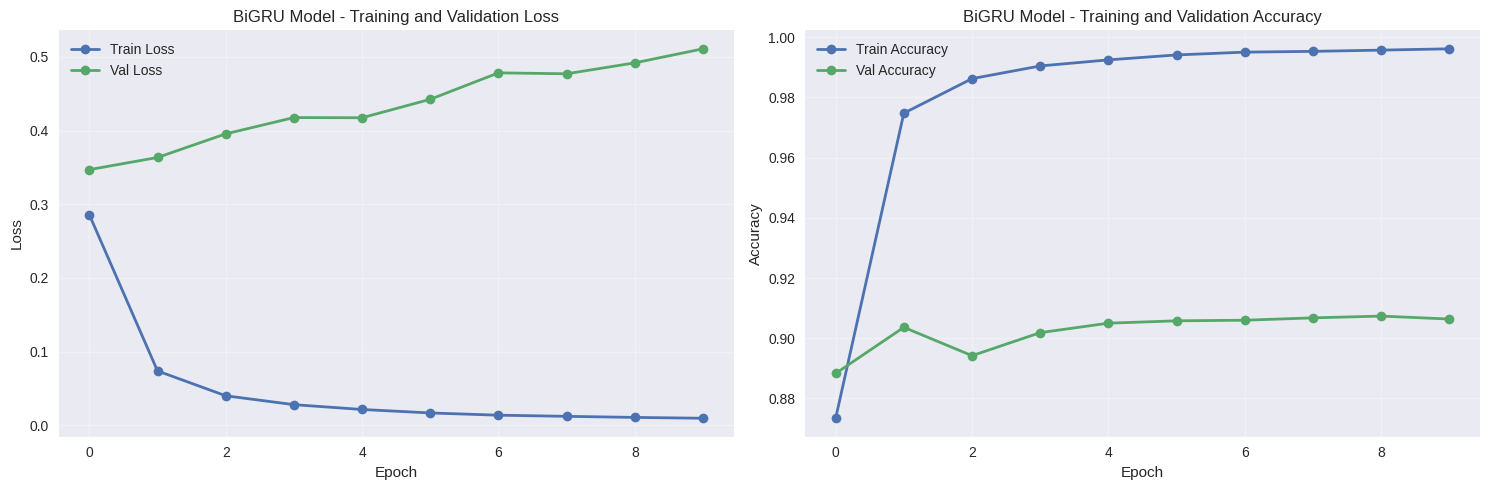

In [172]:
# ========================
# 8. PLOT TRAINING HISTORY - Bi-GRU
# ========================

plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', marker='o', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('BiGRU Model - Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='o', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('BiGRU Model - Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('BiGRU_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

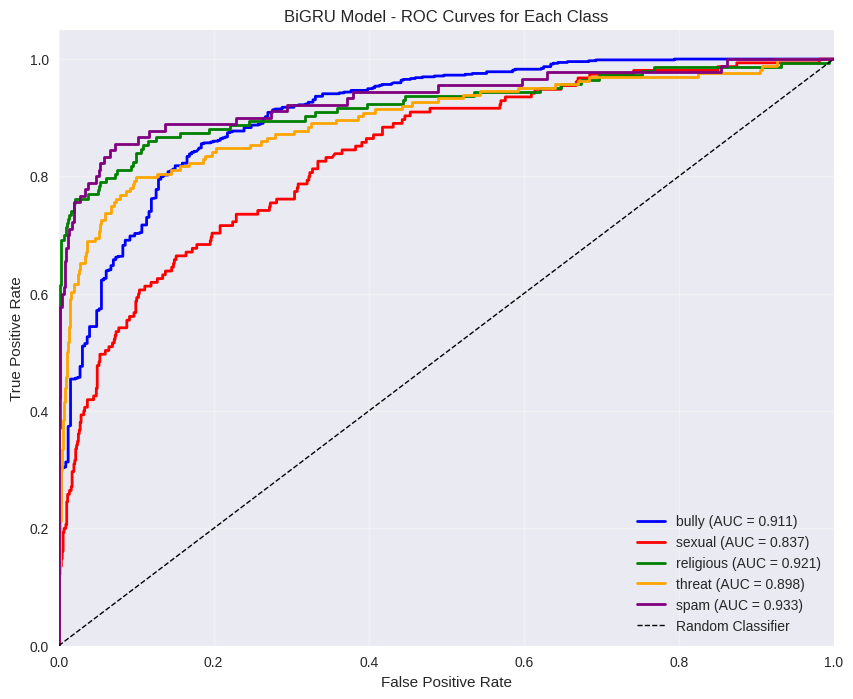

In [173]:
# ========================
# 9. PLOT ROC CURVES - Bi-GRU
# ========================

# Plot ROC curves for each class
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple']

for i, label in enumerate(label_cols):
    try:
        fpr, tpr, _ = roc_curve(test_labels[:, i], test_probs[:, i])
        auc = roc_auc_score(test_labels[:, i], test_probs[:, i])
        plt.plot(fpr, tpr, color=colors[i], linewidth=2, 
                label=f'{label} (AUC = {auc:.3f})')
    except ValueError:
        continue

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('BiGRU Model - ROC Curves for Each Class')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('BiGRU_ROC_curves.png', dpi=300, bbox_inches='tight')
plt.show()


COMPREHENSIVE CONFUSION MATRIX


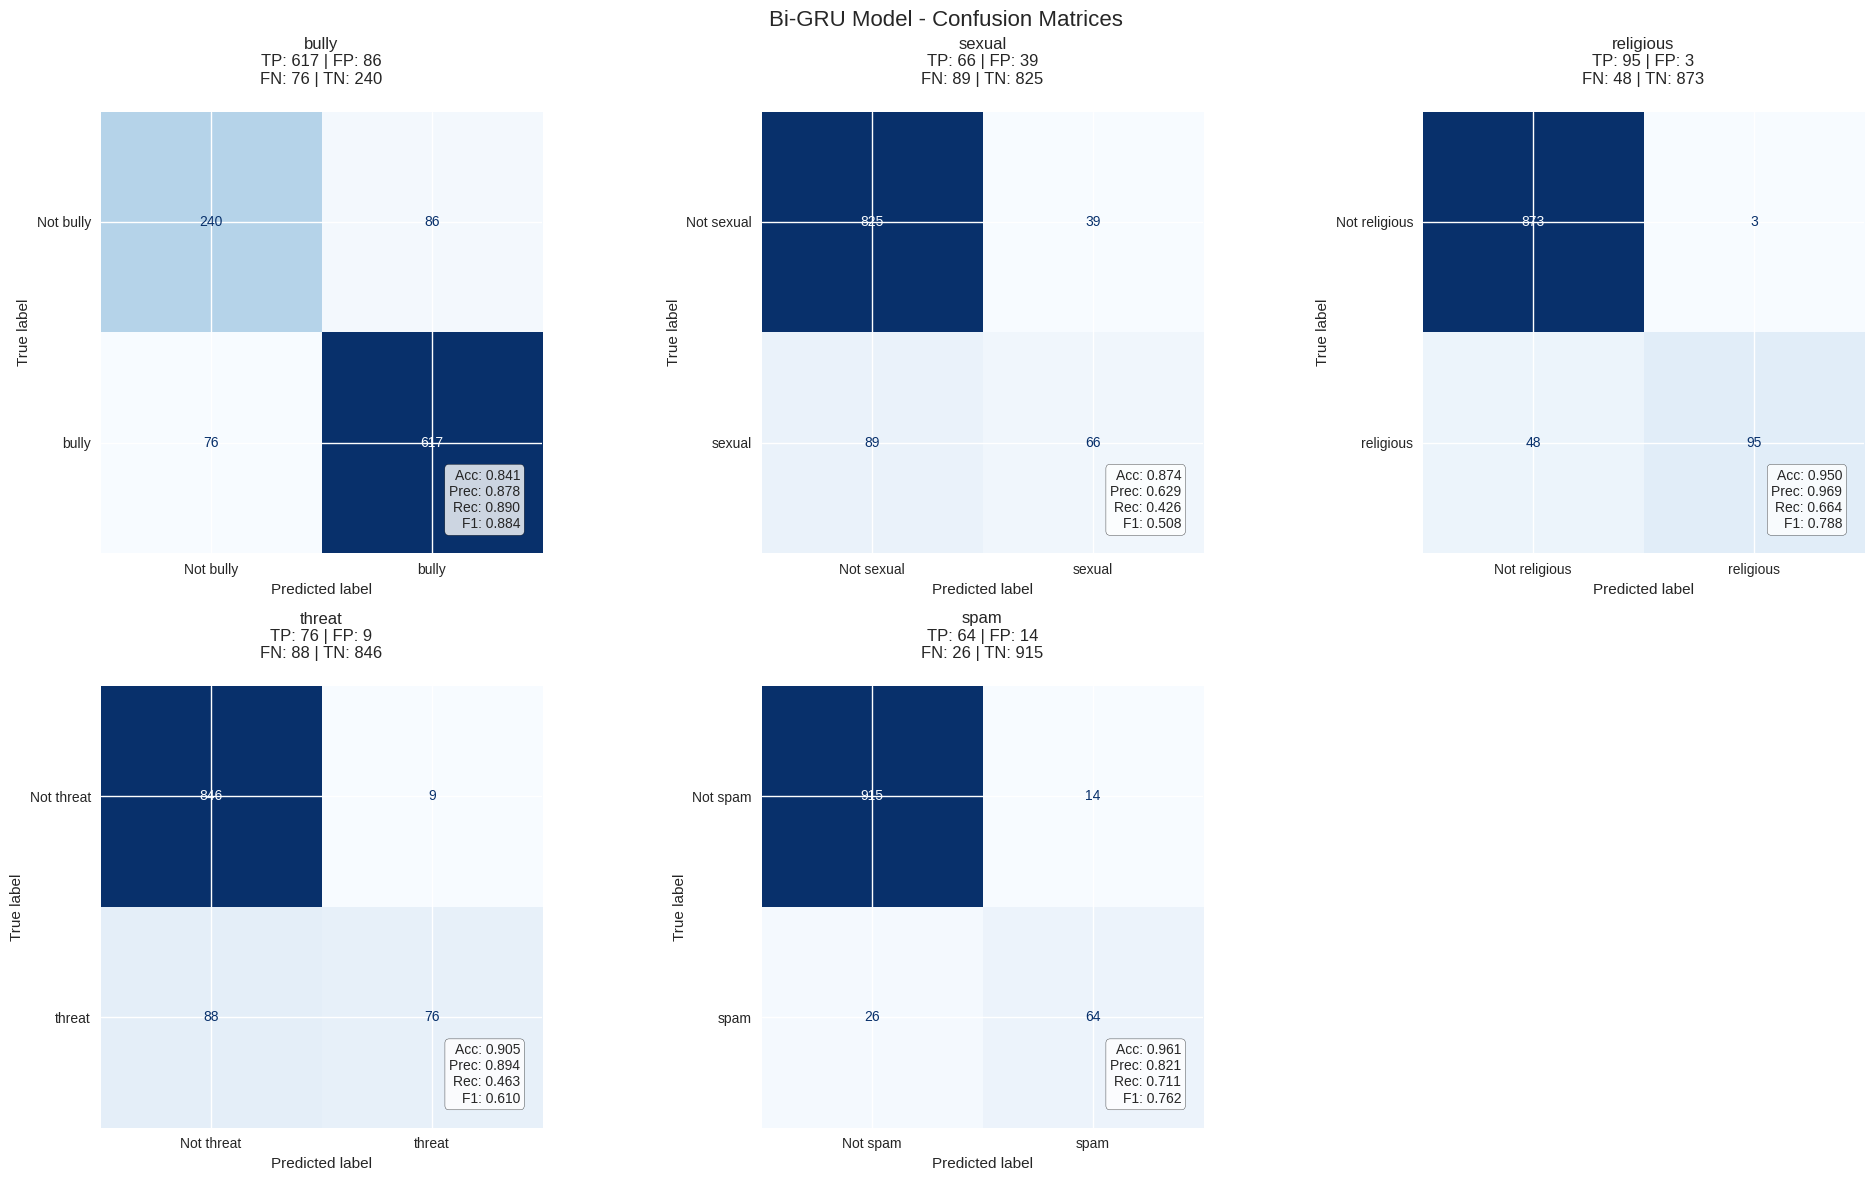

In [174]:
# Add this import at the top
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay

# ========================
# CONFUSION MATRIX SECTION 
# ========================

print(f"\n{'='*50}")
print("COMPREHENSIVE CONFUSION MATRIX")
print(f"{'='*50}")

# Create multilabel confusion matrix
mcm = multilabel_confusion_matrix(test_labels, test_preds)

# Plot a single comprehensive figure
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for i, (label, cm) in enumerate(zip(label_cols, mcm)):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not '+label, label])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f'{label}\nTP: {cm[1,1]} | FP: {cm[0,1]}\nFN: {cm[1,0]} | TN: {cm[0,0]}', 
                     fontsize=12, pad=20)
    
    # Calculate metrics
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    
    # Add metrics as text
    metrics_text = f'Acc: {accuracy:.3f}\nPrec: {precision:.3f}\nRec: {recall:.3f}\nF1: {f1:.3f}'
    axes[i].text(0.95, 0.05, metrics_text, transform=axes[i].transAxes, 
                verticalalignment='bottom', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                fontsize=10)

# Hide the last subplot if we have odd number of labels
if len(label_cols) < len(axes):
    for i in range(len(label_cols), len(axes)):
        axes[i].set_visible(False)

plt.suptitle('Bi-GRU Model - Confusion Matrices', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()



In [175]:
# ========================
# 10. SAMPLE PREDICTIONS - Bi-GRU
# ========================

def predict_cyberbullying_bigru(text, model, vocab, device, threshold=0.5):
    """Predict cyberbullying categories for a single text using BiGRU model"""
    model.eval()
    
    # Tokenize and convert to indices
    tokens = text.split()[:MAX_LEN]
    input_ids = []
    for token in tokens:
        if token in vocab:
            input_ids.append(vocab[token])
        else:
            input_ids.append(vocab['<UNK>'])
    
    # Padding
    if len(input_ids) < MAX_LEN:
        input_ids = input_ids + [vocab['<PAD>']] * (MAX_LEN - len(input_ids))
    else:
        input_ids = input_ids[:MAX_LEN]
    
    input_ids = torch.tensor(input_ids, dtype=torch.long).unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = model(input_ids)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
        preds = (probs > threshold).astype(int)
    
    results = {label: {'prediction': int(pred), 'probability': float(prob)} 
               for label, pred, prob in zip(label_cols, preds, probs)}
    
    return results

# Display 3 sample predictions from test data
print(f"\n{'='*50}")
print("SAMPLE PREDICTIONS FROM TEST DATA - BiGRU")
print(f"{'='*50}")

# Get 3 random samples from test set
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 3, replace=False)

for i, idx in enumerate(sample_indices, 1):
    sample_text = X_test[idx]
    true_labels = y_test[idx]
    
    print(f"\nSample {i}:")
    print(f"Text: {sample_text}")
    
    # Get predictions
    predictions = predict_cyberbullying_bigru(sample_text, model, vocab, device)
    
    print("Predictions:")
    for label in label_cols:
        pred = predictions[label]['prediction']
        prob = predictions[label]['probability']
        true = int(true_labels[label_cols.index(label)])
        
        status = "✓" if pred == true else "✗"
        print(f"  {label}: {status} Pred={pred} (prob: {prob:.3f}), True={true}")


SAMPLE PREDICTIONS FROM TEST DATA - BiGRU

Sample 1:
Text: চলচ্চিত্র জগতে জাহিদের কি অবদান আরেকজনকে কিভাবে অপমান করে তাকে জুতাপেটা করা দরকার
Predictions:
  bully: ✓ Pred=1 (prob: 1.000), True=1
  sexual: ✓ Pred=0 (prob: 0.000), True=0
  religious: ✓ Pred=0 (prob: 0.000), True=0
  threat: ✗ Pred=0 (prob: 0.015), True=1
  spam: ✓ Pred=0 (prob: 0.000), True=0

Sample 2:
Text: সবার সাপোর্ট চাই ভাই আইডিটা ফিরিয়ে গেছেএকটু সাপোর্ট কইরা দিয়েন
Predictions:
  bully: ✓ Pred=0 (prob: 0.000), True=0
  sexual: ✓ Pred=0 (prob: 0.000), True=0
  religious: ✓ Pred=0 (prob: 0.000), True=0
  threat: ✓ Pred=0 (prob: 0.000), True=0
  spam: ✓ Pred=1 (prob: 0.999), True=1

Sample 3:
Text: দুধটা খুইলা একটু ভালো করে করলা একটু মজা লাগবে
Predictions:
  bully: ✓ Pred=1 (prob: 0.999), True=1
  sexual: ✗ Pred=0 (prob: 0.055), True=1
  religious: ✓ Pred=0 (prob: 0.000), True=0
  threat: ✓ Pred=0 (prob: 0.000), True=0
  spam: ✓ Pred=0 (prob: 0.000), True=0


# ================== END ======================

# ================ Machine learning based Models ==========================

In [176]:
# Bengali Multilabel Cyberbullying Detection with Traditional ML Models
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multioutput import MultiOutputClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, hamming_loss, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

In [177]:
# ========================
# 2. TF-IDF VECTORIZATION
# ========================

print("\n" + "="*50)
print("TF-IDF VECTORIZATION")
print("="*50)

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2),
    stop_words=None  # For Bengali, you might want to add custom stop words
)

# Fit and transform on training data
print("Fitting TF-IDF vectorizer...")
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF features: {X_train_tfidf.shape[1]}")
print(f"Train TF-IDF shape: {X_train_tfidf.shape}")
print(f"Val TF-IDF shape: {X_val_tfidf.shape}")
print(f"Test TF-IDF shape: {X_test_tfidf.shape}")


TF-IDF VECTORIZATION
Fitting TF-IDF vectorizer...
TF-IDF features: 10000
Train TF-IDF shape: (25663, 10000)
Val TF-IDF shape: (1019, 10000)
Test TF-IDF shape: (1019, 10000)


In [178]:
# ========================
# 3. MODEL DEFINITIONS
# ========================

models = {
    'Naive Bayes': MultiOutputClassifier(MultinomialNB()),
    'Random Forest': MultiOutputClassifier(RandomForestClassifier()),
    'K-Nearest Neighbors': MultiOutputClassifier(KNeighborsClassifier(
    )),
    'Logistic Regression': MultiOutputClassifier(LogisticRegression()),
    'XGBoost': MultiOutputClassifier(XGBClassifier())
}

In [179]:
from sklearn.metrics import (
    hamming_loss, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, matthews_corrcoef, cohen_kappa_score
)
import numpy as np

# ========================
# 4. TRAINING AND EVALUATION FUNCTION (with MCC & Kappa)
# ========================

def train_and_evaluate_models(models, X_train, y_train, X_test, y_test, label_cols):
    results = {}
    
    for model_name, model in models.items():
        print(f"\n{'='*50}")
        print(f"TRAINING: {model_name}")
        print(f"{'='*50}")
        
        # Train model
        print(f"Training {model_name}...")
        model.fit(X_train, y_train)
        
        # Predict on test set
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)
        
        # Convert probability predictions to proper format
        y_pred_proba_processed = []
        for i in range(len(label_cols)):
            if hasattr(y_pred_proba[i], 'shape') and len(y_pred_proba[i].shape) > 1:
                y_pred_proba_processed.append(y_pred_proba[i][:, 1])
            else:
                y_pred_proba_processed.append(y_pred_proba[i])
        
        y_pred_proba_processed = np.array(y_pred_proba_processed).T
        
        # Calculate metrics
        accuracy = np.mean(y_pred == y_test)
        h_loss = hamming_loss(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='micro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='micro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='micro', zero_division=0)
        
        # Calculate AUC-ROC for each class
        auc_scores = {}
        for i, label in enumerate(label_cols):
            try:
                auc = roc_auc_score(y_test[:, i], y_pred_proba_processed[:, i])
                auc_scores[label] = auc
            except ValueError:
                auc_scores[label] = np.nan
        
        # Calculate micro and macro AUC
        try:
            micro_auc = roc_auc_score(y_test, y_pred_proba_processed, average='micro')
            macro_auc = roc_auc_score(y_test, y_pred_proba_processed, average='macro')
        except ValueError:
            micro_auc = np.nan
            macro_auc = np.nan

        # ======================================================
        # Per-class MCC and Cohen's Kappa
        # ======================================================
        mcc_scores = {}
        kappa_scores = {}

        for i, label in enumerate(label_cols):
            try:
                mcc = matthews_corrcoef(y_test[:, i], y_pred[:, i])
                kappa = cohen_kappa_score(y_test[:, i], y_pred[:, i])
                mcc_scores[label] = mcc
                kappa_scores[label] = kappa
            except ValueError:
                mcc_scores[label] = np.nan
                kappa_scores[label] = np.nan

        avg_mcc = np.nanmean(list(mcc_scores.values()))
        avg_kappa = np.nanmean(list(kappa_scores.values()))
        
        # Store results
        results[model_name] = {
            'model': model,
            'y_pred': y_pred,
            'y_pred_proba': y_pred_proba_processed,
            'accuracy': accuracy,
            'hamming_loss': h_loss,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'auc_scores': auc_scores,
            'micro_auc': micro_auc,
            'macro_auc': macro_auc,
            'mcc_scores': mcc_scores,
            'kappa_scores': kappa_scores,
            'avg_mcc': avg_mcc,
            'avg_kappa': avg_kappa
        }
        
        # Print results
        print(f"\n{model_name} Results:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Hamming Loss: {h_loss:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1-Score: {f1:.4f}")
        print(f"Micro AUC: {micro_auc:.4f}")
        print(f"Macro AUC: {macro_auc:.4f}")
        
        print(f"\nPer-class AUC scores:")
        for label, auc in auc_scores.items():
            print(f"  {label}: {auc:.4f}")

        print(f"\nPer-class MCC & Cohen's Kappa:")
        for label in label_cols:
            print(f"  {label}: MCC = {mcc_scores[label]:.4f}, Cohen's Kappa = {kappa_scores[label]:.4f}")

        print(f"\nAverage Scores:")
        print(f"MCC: {avg_mcc:.4f}")
        print(f"Cohen's Kappa: {avg_kappa:.4f}")
        
        print(f"\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=label_cols, zero_division=0))
    
    return results


In [180]:
# ========================
# 5. TRAIN ALL MODELS
# ========================

print("\n" + "="*50)
print("TRAINING ALL ML MODELS")
print("="*50)

results = train_and_evaluate_models(models, X_train_tfidf, y_train, X_test_tfidf, y_test, label_cols)


TRAINING ALL ML MODELS

TRAINING: Naive Bayes
Training Naive Bayes...

Naive Bayes Results:
Accuracy: 0.8801
Hamming Loss: 0.1199
Precision: 0.7646
Recall: 0.7357
F1-Score: 0.7499
Micro AUC: 0.9093
Macro AUC: 0.8499

Per-class AUC scores:
  bully: 0.8321
  sexual: 0.7823
  religious: 0.8894
  threat: 0.8299
  spam: 0.9158

Per-class MCC & Cohen's Kappa:
  bully: MCC = 0.4886, Cohen's Kappa = 0.4764
  sexual: MCC = 0.3983, Cohen's Kappa = 0.3713
  religious: MCC = 0.6655, Cohen's Kappa = 0.6630
  threat: MCC = 0.4507, Cohen's Kappa = 0.4427
  spam: MCC = 0.7015, Cohen's Kappa = 0.7013

Average Scores:
MCC: 0.5409
Cohen's Kappa: 0.5310

Classification Report:
              precision    recall  f1-score   support

       bully       0.80      0.91      0.85       693
      sexual       0.65      0.33      0.44       155
   religious       0.76      0.66      0.71       143
      threat       0.62      0.45      0.52       164
        spam       0.71      0.74      0.73        90

   micr

In [181]:
# ========================
# 6. COMPARATIVE ANALYSIS
# ========================

print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)

# Create comparison dataframe
comparison_data = []
for model_name, result in results.items():
    comparison_data.append({
        'Model': model_name,
        'Accuracy': result['accuracy'],
        'Hamming Loss': result['hamming_loss'],
        'Precision': result['precision'],
        'Recall': result['recall'],
        'F1-Score': result['f1_score'],
        'Micro AUC': result['micro_auc'],
        'Macro AUC': result['macro_auc'],
        'Avg MCC': result['avg_mcc'],
        'Avg Cohen Kappa': result['avg_kappa']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(4)

print("\nModel Comparison Table:")
print(comparison_df.to_string(index=False))



MODEL COMPARISON

Model Comparison Table:
              Model  Accuracy  Hamming Loss  Precision  Recall  F1-Score  Micro AUC  Macro AUC  Avg MCC  Avg Cohen Kappa
        Naive Bayes    0.8801        0.1199     0.7646  0.7357    0.7499     0.9093     0.8499   0.5409           0.5310
      Random Forest    0.8822        0.1178     0.7812  0.7197    0.7492     0.9133     0.8568   0.5352           0.5225
K-Nearest Neighbors    0.8232        0.1768     0.6156  0.7357    0.6703     0.8413     0.7517   0.4080           0.3903
Logistic Regression    0.8832        0.1168     0.7617  0.7598    0.7608     0.9186     0.8625   0.5663           0.5626
            XGBoost    0.8742        0.1258     0.7517  0.7245    0.7378     0.9014     0.8306   0.5055           0.4958


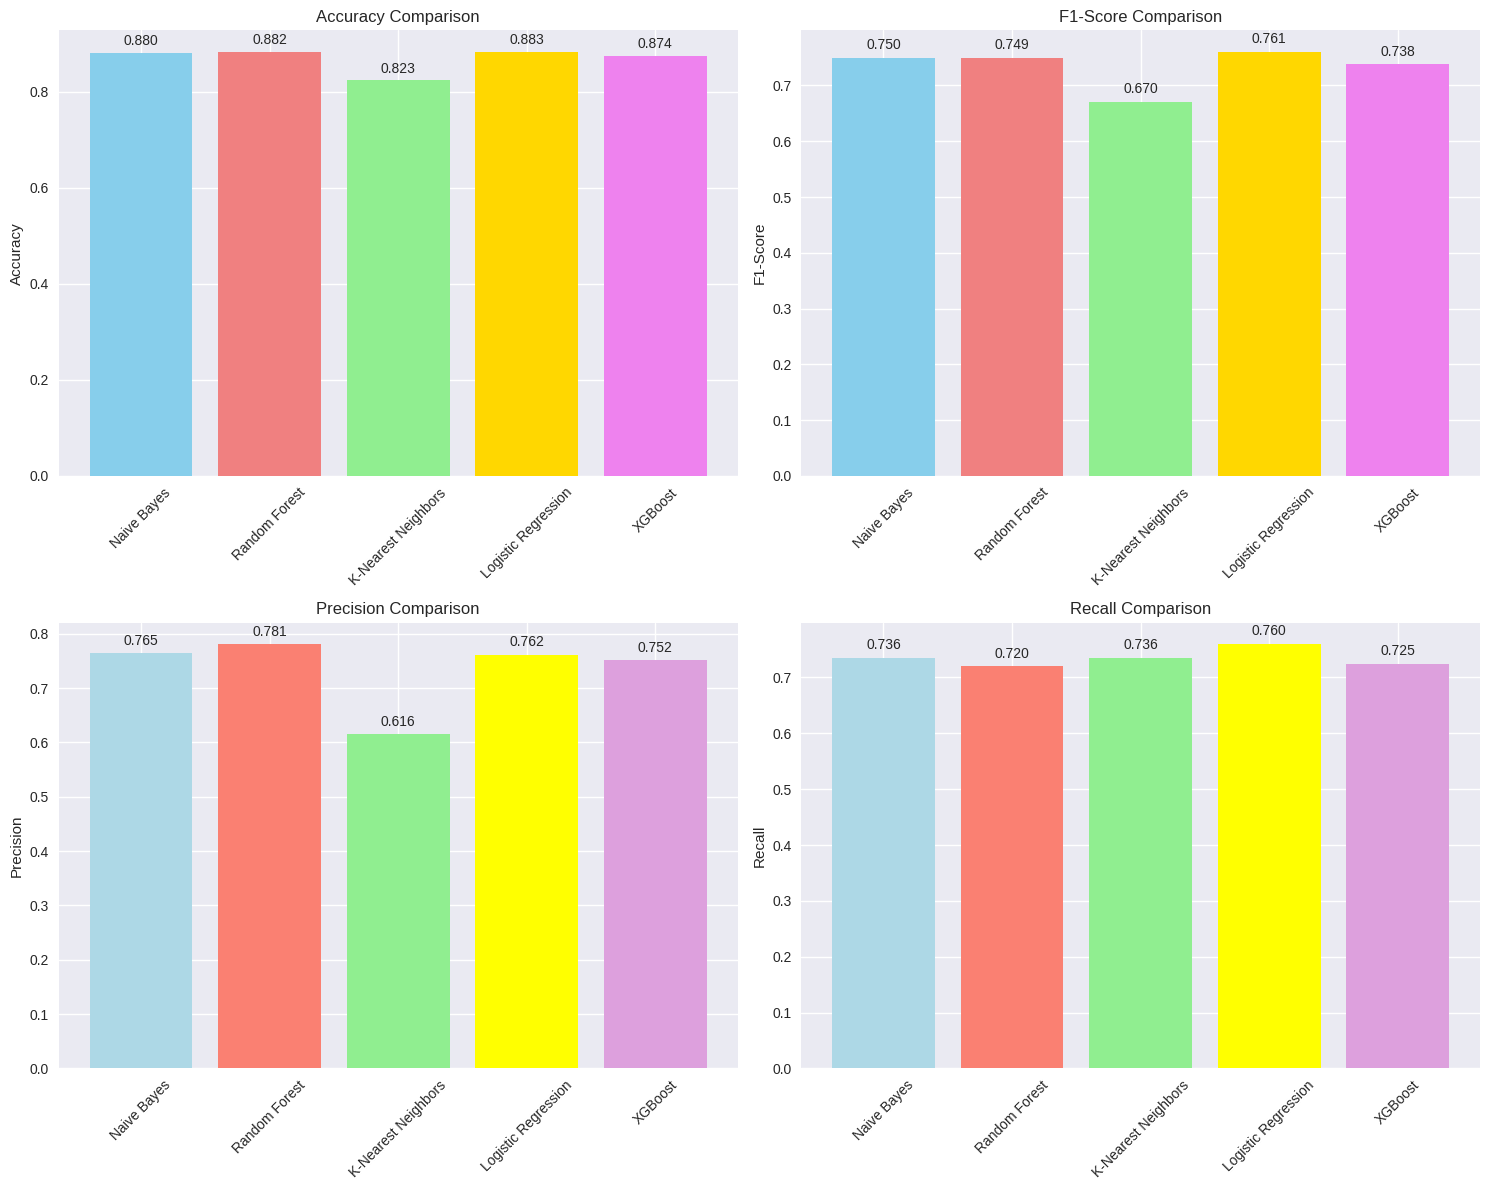

In [182]:
# ========================
# 7. VISUALIZATIONS
# ========================

# Set style
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Accuracy and F1-Score Comparison
metrics_1 = ['Accuracy', 'F1-Score']
for i, metric in enumerate(metrics_1):
    axes[0, i].bar(comparison_df['Model'], comparison_df[metric], color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'violet'])
    axes[0, i].set_title(f'{metric} Comparison')
    axes[0, i].set_ylabel(metric)
    axes[0, i].tick_params(axis='x', rotation=45)
    # Add value labels on bars
    for j, v in enumerate(comparison_df[metric]):
        axes[0, i].text(j, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# 2. Precision and Recall Comparison
metrics_2 = ['Precision', 'Recall']
for i, metric in enumerate(metrics_2):
    axes[1, i].bar(comparison_df['Model'], comparison_df[metric], color=['lightblue', 'salmon', 'lightgreen', 'yellow', 'plum'])
    axes[1, i].set_title(f'{metric} Comparison')
    axes[1, i].set_ylabel(metric)
    axes[1, i].tick_params(axis='x', rotation=45)
    # Add value labels on bars
    for j, v in enumerate(comparison_df[metric]):
        axes[1, i].text(j, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('ML_Models_Performance_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

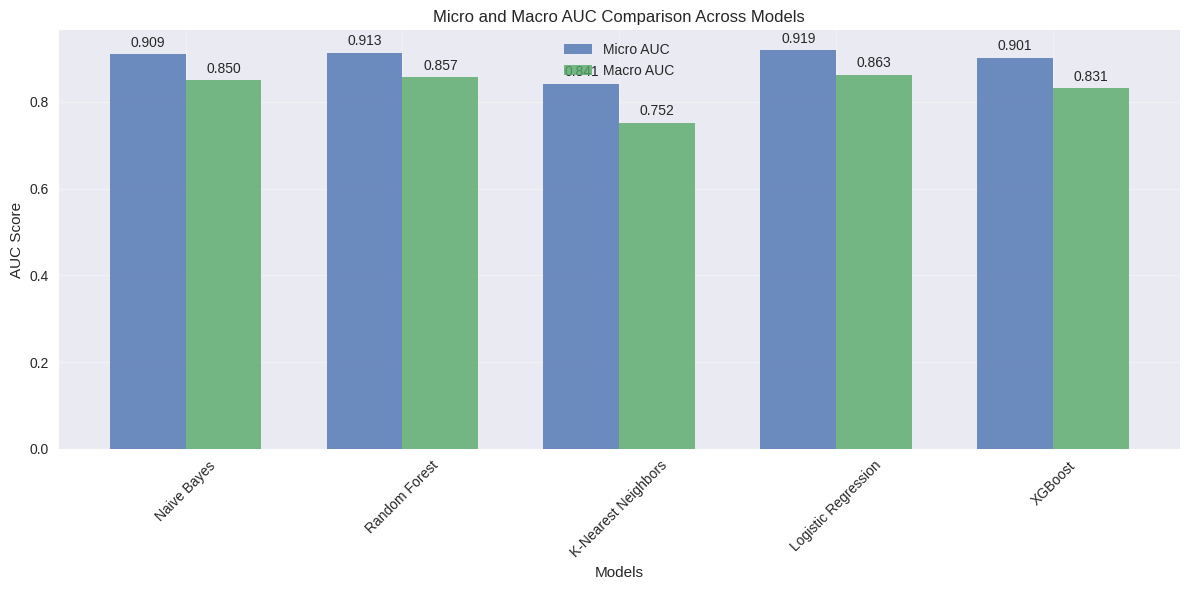

In [183]:
# AUC Comparison Plot
plt.figure(figsize=(12, 6))
x_pos = np.arange(len(comparison_df))
width = 0.35

plt.bar(x_pos - width/2, comparison_df['Micro AUC'], width, label='Micro AUC', alpha=0.8)
plt.bar(x_pos + width/2, comparison_df['Macro AUC'], width, label='Macro AUC', alpha=0.8)

plt.xlabel('Models')
plt.ylabel('AUC Score')
plt.title('Micro and Macro AUC Comparison Across Models')
plt.xticks(x_pos, comparison_df['Model'], rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

# Add value labels
for i, v in enumerate(comparison_df['Micro AUC']):
    plt.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
for i, v in enumerate(comparison_df['Macro AUC']):
    plt.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('ML_Models_AUC_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()